In [1]:
# ============================================================
# TITLE: Bitcoin Price Prediction using Deep Learning
# MAI 604 - Group Project | Instructor: Firuz Kamalov
# Dataset: Bitcoin Historical Price Data (2017–2026)
# Students:
# Saeeda Amer 20250006821
# Shamsa Alsuwaidi 20250007177
# Amna Aljaroodi  20250007933
# ============================================================

In [2]:
# ============================================================
# SECTION 1: Install & Import Libraries
# NEW: Added requests for Coinmetrics on-chain API.
# ============================================================

!pip install yfinance pytrends pandas-datareader transformers --quiet
!pip install torchviz --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib.parse
from torchviz import make_dot
import torch
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")


✅ Libraries imported successfully.
PyTorch version: 2.10.0+cu128


In [3]:
# ============================================================
# SECTION 2: Load Bitcoin Dataset
# What it does: Downloads Bitcoin (BTC-USD) historical OHLCV data
# from Yahoo Finance covering 2017 to TODAY (live, always current).
# Displays the first few rows and dataset shape so we understand
# what we're working with.
# ============================================================

TODAY = pd.Timestamp.today().strftime('%Y-%m-%d')
print(f'📅 Fetching data up to: {TODAY}')

df = yf.download('BTC-USD', start='2017-01-01', end=TODAY)
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)
# Drop the ticker level from the column MultiIndex for cleaner single-level column names
df.columns = df.columns.droplevel(1)
# Remove 'Adj Close' if present and not needed for this analysis
if 'Adj Close' in df.columns:
    df = df.drop(columns=['Adj Close'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()


📅 Fetching data up to: 2026-04-26


[*********************100%***********************]  1 of 1 completed

Dataset shape: (3402, 5)
Date range: 2017-01-01 00:00:00 → 2026-04-25 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008


In [4]:
# ============================================================
# SECTION 2B: External Data Collection
# NEW: Fetches 4 external data sources and merges them onto
# the BTC trading-day index with forward fill:
#   1. Fear & Greed Index  — alternative.me (free, no key)
#   2. Cross-Asset Prices  — ETH, S&P500, NASDAQ, VIX, Gold, Oil
#   3. Google Trends       — "bitcoin" search interest (pytrends)
#   4. Macro Indicators    — Fed Funds Rate + CPI via FRED
# ============================================================

print("=" * 55)
print("  Fetching external data sources...")
print("=" * 55)

# ── 1. Fear & Greed Index ──────────────────────────────────
print("\n📊 1/4  Fear & Greed Index (alternative.me)...")
try:
    url = "https://api.alternative.me/fng/?limit=0&format=json&date_format=us"
    r   = requests.get(url, timeout=15)
    fng_raw = r.json()['data']
    fng_df  = pd.DataFrame(fng_raw)
    fng_df['timestamp'] = pd.to_datetime(fng_df['timestamp'])
    fng_df  = fng_df.set_index('timestamp')[['value']].rename(columns={'value': 'Fear_Greed'})
    fng_df['Fear_Greed'] = fng_df['Fear_Greed'].astype(float)
    fng_df  = fng_df.sort_index()
    print(f"   ✅ {len(fng_df)} days fetched")
except Exception as e:
    print(f"   ⚠️  Failed ({e}). Filling with neutral 50.")
    fng_df = pd.DataFrame({'Fear_Greed': 50.0}, index=df.index)

# ── 2. Cross-Asset Data ────────────────────────────────────
print("\n📈 2/4  Cross-asset data (ETH, SP500, NASDAQ, VIX, Gold, Oil)...")
asset_tickers = {
    'ETH-USD': ('ETH',    'return'),
    '^GSPC':   ('SP500',  'return'),
    '^IXIC':   ('NASDAQ', 'return'),
    '^VIX':    ('VIX',    'raw'),
    'GC=F':    ('Gold',   'return'),
    'CL=F':    ('Oil',    'return'),
}
asset_df = pd.DataFrame(index=df.index)
for ticker, (name, kind) in asset_tickers.items():
    try:
        tmp = yf.download(ticker, start='2017-01-01', end=TODAY,
                          auto_adjust=True, progress=False)
        if isinstance(tmp.columns, pd.MultiIndex):
            tmp.columns = tmp.columns.droplevel(1)
        close = tmp['Close'].reindex(df.index).ffill().bfill()
        if kind == 'raw':
            asset_df[name]            = close
        else:
            asset_df[f'{name}_Return'] = close.pct_change()
        print(f"   ✅ {name}")
    except Exception as e:
        print(f"   ⚠️  {name} failed ({e}). Filling with 0.")
        col = name if kind == 'raw' else f'{name}_Return'
        asset_df[col] = 0.0

# ── 3. Google Trends ───────────────────────────────────────
print("\n🔍 3/4  Google Trends ('bitcoin' search interest)...")
try:
    from pytrends.request import TrendReq
    pytrends = TrendReq(hl='en-US', tz=0)
    pytrends.build_payload(['bitcoin'], timeframe='today 5-y')
    trends_raw = pytrends.interest_over_time()
    if trends_raw.empty:
        raise ValueError("Empty response from pytrends")
    trends_df = trends_raw[['bitcoin']].rename(columns={'bitcoin': 'Google_Trends'})
    trends_df = trends_df.reindex(df.index).ffill().bfill()
    print(f"   ✅ Google Trends fetched ({len(trends_df)} rows)")
except Exception as e:
    print(f"   ⚠️  Failed ({e}). Filling with neutral 50.")
    trends_df = pd.DataFrame({'Google_Trends': 50.0}, index=df.index)

# ── 4. Macro Data via FRED ─────────────────────────────────
print("\n🏦 4/4  Macro data (Fed Funds Rate + CPI via FRED)...")
try:
    import pandas_datareader as pdr
    fed_raw = pdr.get_data_fred('FEDFUNDS', start='2017-01-01', end=TODAY)
    cpi_raw = pdr.get_data_fred('CPIAUCSL', start='2017-01-01', end=TODAY)
    # Monthly → daily via forward fill
    fed_daily  = fed_raw['FEDFUNDS'].reindex(df.index, method='ffill').bfill()
    cpi_yoy    = cpi_raw['CPIAUCSL'].pct_change(12).mul(100)
    cpi_daily  = cpi_yoy.reindex(df.index, method='ffill').bfill()
    macro_df   = pd.DataFrame({'FedFunds': fed_daily, 'CPI_YoY': cpi_daily}, index=df.index)
    print("   ✅ Fed Funds Rate + CPI (YoY %) fetched")
except Exception as e:
    print(f"   ⚠️  FRED failed ({e}). Using neutral placeholders.")
    macro_df = pd.DataFrame({'FedFunds': 2.0, 'CPI_YoY': 2.0}, index=df.index)

# ── Merge all onto BTC index ───────────────────────────────

# Define all columns that will be added by the joins in this section
columns_to_add = [
    'Fear_Greed',
    'ETH_Return', 'SP500_Return', 'NASDAQ_Return', 'VIX', 'Gold_Return', 'Oil_Return',
    'Google_Trends',
    'FedFunds', 'CPI_YoY'
]

# Drop these columns from df if they already exist, to prevent 'columns overlap' error on re-run
for col in columns_to_add:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.join(fng_df.reindex(df.index).ffill().bfill(),    how='left')
df = df.join(asset_df,                                    how='left')
df = df.join(trends_df.reindex(df.index).ffill().bfill(), how='left')
df = df.join(macro_df,                                    how='left')
df = df.ffill().bfill()

print(f"\n✅ All external data merged. Dataset shape: {df.shape}")
new_cols = [c for c in df.columns if c not in ['Open','High','Low','Close','Volume']]
print(f"   External columns: {new_cols}")


  Fetching external data sources...

📊 1/4  Fear & Greed Index (alternative.me)...
   ✅ 3003 days fetched

📈 2/4  Cross-asset data (ETH, SP500, NASDAQ, VIX, Gold, Oil)...
   ✅ ETH
   ✅ SP500
   ✅ NASDAQ
   ✅ VIX
   ✅ Gold
   ✅ Oil

🔍 3/4  Google Trends ('bitcoin' search interest)...
   ✅ Google Trends fetched (3402 rows)

🏦 4/4  Macro data (Fed Funds Rate + CPI via FRED)...
   ✅ Fed Funds Rate + CPI (YoY %) fetched

✅ All external data merged. Dataset shape: (3402, 15)
   External columns: ['Fear_Greed', 'ETH_Return', 'SP500_Return', 'NASDAQ_Return', 'VIX', 'Gold_Return', 'Oil_Return', 'Google_Trends', 'FedFunds', 'CPI_YoY']


In [5]:
# ============================================================
# SECTION 2C: FinBERT News Sentiment
# Uses ProsusAI/finbert to score Bitcoin news headlines.
# Sources: GDELT (with retry+backoff) → RSS feeds → GDELT tone → neutral.
# Set RUN_FINBERT = True to enable. GPU recommended.
# ============================================================
RUN_FINBERT = True   # ← Set True to enable
if RUN_FINBERT:
    import time
    import xml.etree.ElementTree as ET
    from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

    print("🤖 Loading FinBERT (ProsusAI/finbert)...")
    fb_tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    fb_model     = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
    fb_pipeline  = pipeline("sentiment-analysis", model=fb_model,
                             tokenizer=fb_tokenizer, truncation=True, max_length=512)
    print("✅ FinBERT loaded.")

    # ── Helper: GDELT article list with retry + backoff ──────────────────────
    def _gdelt_headlines(query, timespan="2weeks", max_records=100, retries=3):
        url = (
            "https://api.gdeltproject.org/api/v2/doc/doc"
            f"?query={urllib.parse.quote(query)}"
            "&mode=artlist"
            f"&maxrecords={max_records}"
            f"&timespan={timespan}"
            "&sort=DateDesc&format=json"
        )
        for attempt in range(retries):
            try:
                r = requests.get(url, timeout=25, headers={"User-Agent": "Mozilla/5.0"})
                r.raise_for_status()
                if not r.text.strip():
                    raise ValueError("GDELT returned empty body.")
                return [a.get("title", "") for a in r.json().get("articles", []) if a.get("title")]
            except Exception as ex:
                wait = 4 * (attempt + 1)          # 4s, 8s, 12s
                if attempt < retries - 1:
                    print(f"   ⚠️  '{query}' attempt {attempt+1} failed: {ex}. Retrying in {wait}s…")
                    time.sleep(wait)
                else:
                    raise                          # re-raise after last attempt

    # ── Helper: RSS feed fallback (no API key required) ───────────────────────
    RSS_FEEDS = [
        ("CoinDesk",       "https://www.coindesk.com/arc/outboundfeeds/rss/"),
        ("Cointelegraph",  "https://cointelegraph.com/rss"),
        ("Bitcoin Magazine","https://bitcoinmagazine.com/.rss/full/"),
    ]

    def _rss_headlines(feed_url, max_items=60):
        r = requests.get(feed_url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        root = ET.fromstring(r.content)
        titles = []
        for item in root.iter("item"):
            t = item.findtext("title")
            if t:
                titles.append(t.strip())
            if len(titles) >= max_items:
                break
        return titles

    # ── Stage 1: GDELT article list ───────────────────────────────────────────
    headlines = []
    for q in ["bitcoin price", "cryptocurrency bitcoin", "BTC crypto market"]:
        try:
            headlines = _gdelt_headlines(q)
            if headlines:
                print(f"   ✅ {len(headlines)} headlines via GDELT (query: '{q}')")
                break
        except Exception as ex:
            print(f"   ⚠️  GDELT '{q}' failed: {ex}")
        time.sleep(2)                              # brief pause between queries

    # ── Stage 2: RSS feeds ────────────────────────────────────────────────────
    if not headlines:
        print("   ↩️  GDELT unavailable — trying RSS feeds…")
        for name, feed_url in RSS_FEEDS:
            try:
                headlines = _rss_headlines(feed_url)
                if headlines:
                    print(f"   ✅ {len(headlines)} headlines via {name} RSS")
                    break
            except Exception as ex:
                print(f"   ⚠️  {name} RSS failed: {ex}")

    # ── Stage 3: GDELT tone timeline (no NLP needed) ─────────────────────────
    avg_sentiment = 0.0
    if headlines:
        results = fb_pipeline(headlines[:100])
        scores  = [r["score"] if r["label"] == "positive"
                   else -r["score"] if r["label"] == "negative"
                   else 0.0 for r in results]
        avg_sentiment = float(np.mean(scores))
        pos = sum(1 for r in results if r["label"] == "positive")
        neg = sum(1 for r in results if r["label"] == "negative")
        neu = len(results) - pos - neg
        print(f"\n✅ FinBERT sentiment: {avg_sentiment:+.4f}")
        print(f"   Positive: {pos} | Neutral: {neu} | Negative: {neg}")
    else:
        print("   ↩️  All headline sources failed — falling back to GDELT tone timeline…")
        try:
            tone_url = (
                "https://api.gdeltproject.org/api/v2/tv/tv"
                "?query=bitcoin&mode=timelinetone&format=json&timespan=1month"
            )
            tr   = requests.get(tone_url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
            tr.raise_for_status()
            if not tr.text.strip():
                raise ValueError("Empty tone response.")
            data = tr.json().get("timeline", [{}])[0].get("data", [])
            if data:
                avg_sentiment = float(np.clip(
                    np.mean([d["value"] for d in data]) / 10.0, -1, 1))
                print(f"   ✅ GDELT tone sentiment: {avg_sentiment:+.4f}")
            else:
                raise ValueError("No tone data points returned.")
        except Exception as ex:
            print(f"   ⚠️  Tone fallback failed: {ex}. Using neutral 0.0.")

    print(f"   ℹ️  avg_sentiment = {avg_sentiment:+.4f} — use as live feature in Section 18.")

else:
    print("ℹ️  FinBERT skipped (RUN_FINBERT=False).")
    print("   Fear & Greed Index (Section 2B) already serves as sentiment proxy.")
    print("   Set RUN_FINBERT=True above to enable full headline scoring.")

🤖 Loading FinBERT (ProsusAI/finbert)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ FinBERT loaded.
   ✅ 100 headlines via GDELT (query: 'bitcoin price')

✅ FinBERT sentiment: +0.0780
   Positive: 16 | Neutral: 78 | Negative: 6
   ℹ️  avg_sentiment = +0.0780 — use as live feature in Section 18.


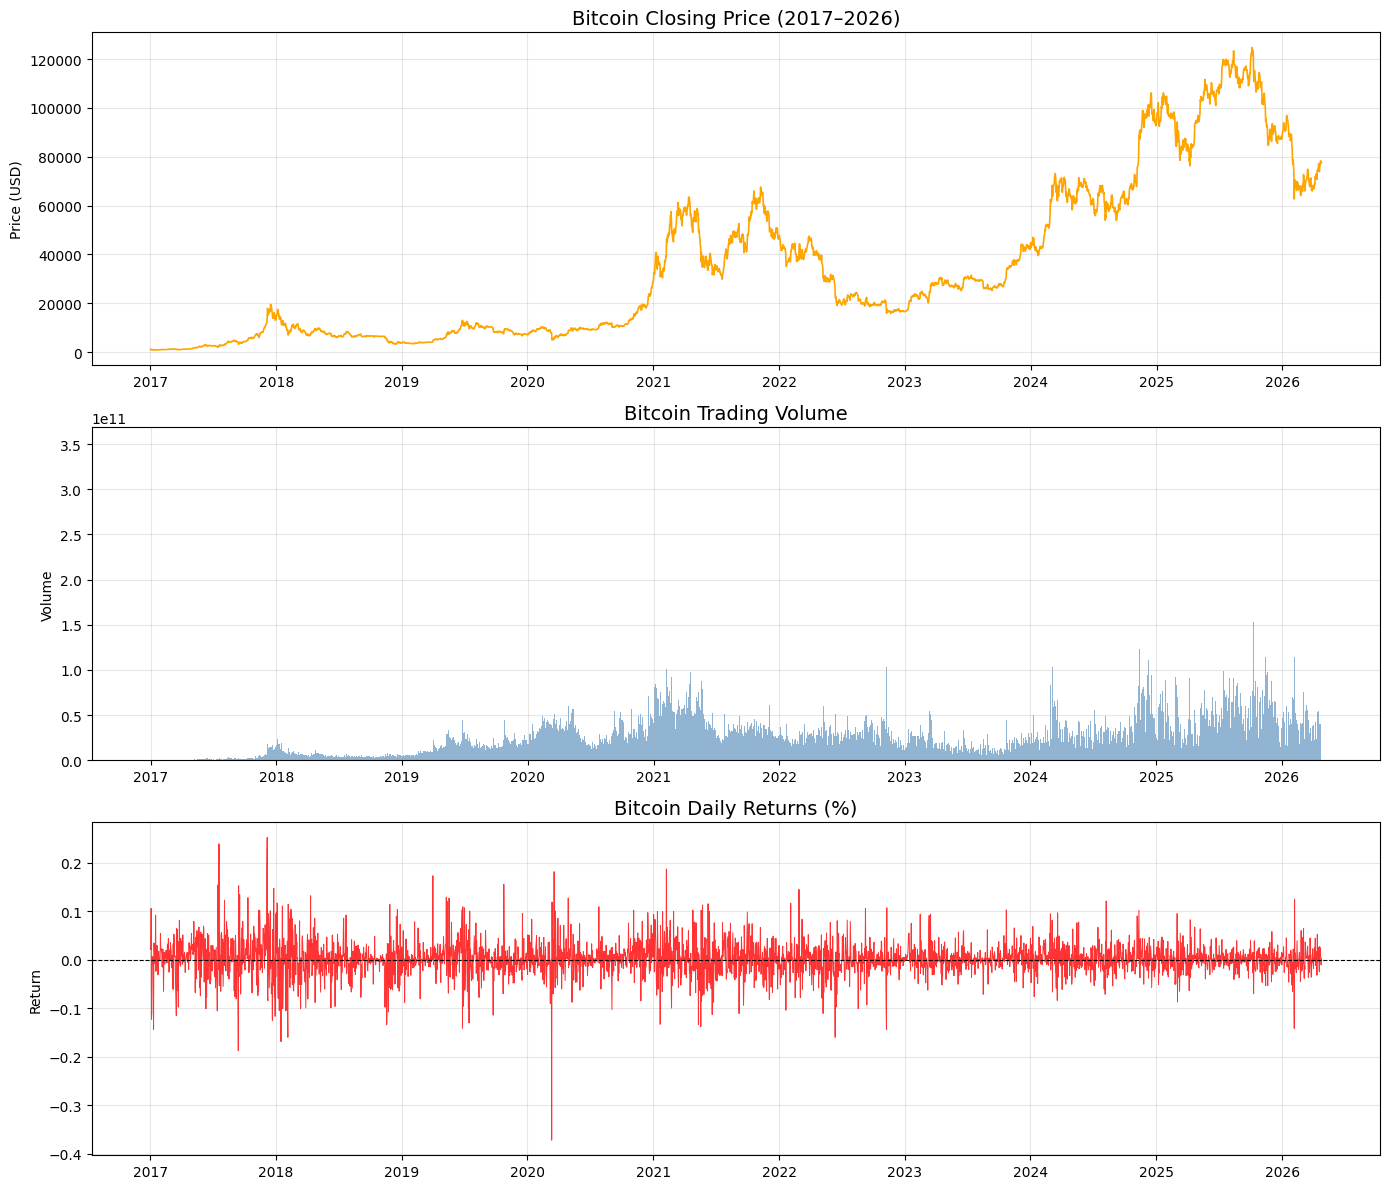


 Descriptive Statistics:
            Open       High        Low      Close        Volume
count    3402.00    3402.00    3402.00    3402.00  3.402000e+03
mean    34984.45   35683.70   34242.61   35005.72  2.763446e+10
std     32554.30   33085.91   31981.20   32556.69  2.255156e+10
min       775.18     823.31     755.76     777.76  6.085170e+07
25%      8205.76    8340.45    7992.71    8206.86  1.109139e+10
50%     23541.64   24107.09   23086.42   23592.34  2.410042e+10
75%     57342.68   58465.70   55673.03   57330.44  3.849531e+10
max    124752.14  126198.07  123196.05  124752.53  3.509679e+11


In [6]:
# ============================================================
# SECTION 3: Exploratory Data Analysis (EDA)
# What it does: Plots the Bitcoin closing price over time and
# shows basic statistics (mean, std, min/max) to understand
# the distribution and trends in the data.
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Plot 1: Closing Price ---
axes[0].plot(df.index, df['Close'], color='orange', linewidth=1.2)
axes[0].set_title(f'Bitcoin Closing Price (2017–{df.index.max().year})', fontsize=14)
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Trading Volume ---
# The columns were flattened earlier, so 'Volume' is now a single-level column name.
axes[1].bar(df.index, df['Volume'], color='steelblue', alpha=0.6, width=1)
axes[1].set_title('Bitcoin Trading Volume', fontsize=14)
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Daily Returns ---
df['Daily_Return'] = df['Close'].pct_change()
axes[2].plot(df.index, df['Daily_Return'], color='red', linewidth=0.7, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Bitcoin Daily Returns (%)', fontsize=14)
axes[2].set_ylabel('Return')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_bitcoin.png', dpi=150)
plt.show()

print("\n Descriptive Statistics:")
print(df[['Open','High','Low','Close','Volume']].describe().round(2))

In [7]:
# ============================================================
# SECTION 4: Feature Engineering
# NEW: Added Bollinger Band Width, MACD, and
#      days_since_halving (Bitcoin halving cycle encoding).
# Halving dates: 2012-11-28, 2016-07-09, 2020-05-11, 2024-04-19
# This captures the 4-year supply-shock cycle reliably.
# ============================================================

# ── Technical Indicators ───────────────────────────────────
df['SMA_7']  = df['Close'].rolling(window=7).mean()
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['EMA_14'] = df['Close'].ewm(span=14, adjust=False).mean()

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs    = gain / (loss + 1e-8)
    return 100 - (100 / (1 + rs))

df['RSI_14']  = compute_rsi(df['Close'], period=14)

# ── Bollinger Band Width (volatility) ─────────────────────
bb_mid         = df['Close'].rolling(20).mean()
bb_std         = df['Close'].rolling(20).std()
df['BB_Width'] = (bb_std * 2) / bb_mid

# ── MACD (momentum) ────────────────────────────────────────
ema12       = df['Close'].ewm(span=12, adjust=False).mean()
ema26       = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']  = ema12 - ema26

# ── NEW: Halving Cycle Encoding ────────────────────────────
# Bitcoin undergoes a block-reward halving roughly every 4 years.
# Each halving historically precedes a major bull run.
# We encode the number of days elapsed since the most recent halving.
HALVING_DATES = pd.to_datetime([
    '2012-11-28',  # Halving 1: 50 → 25 BTC
    '2016-07-09',  # Halving 2: 25 → 12.5 BTC
    '2020-05-11',  # Halving 3: 12.5 → 6.25 BTC
    '2024-04-19',  # Halving 4: 6.25 → 3.125 BTC
])

def days_since_last_halving(date):
    past = [h for h in HALVING_DATES if h <= date]
    if not past:
        return 0
    return (date - max(past)).days

df['Days_Since_Halving'] = [
    days_since_last_halving(d) for d in df.index
]
print("   Halving cycle range:",
      df['Days_Since_Halving'].min(), "→", df['Days_Since_Halving'].max(), "days")

df.dropna(inplace=True)

print(f"\n✅ Features engineered. Dataset shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")


   Halving cycle range: 0 → 1438 days

✅ Features engineered. Dataset shape: (3373, 23)
   Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Fear_Greed', 'ETH_Return', 'SP500_Return', 'NASDAQ_Return', 'VIX', 'Gold_Return', 'Oil_Return', 'Google_Trends', 'FedFunds', 'CPI_YoY', 'Daily_Return', 'SMA_7', 'SMA_30', 'EMA_14', 'RSI_14', 'BB_Width', 'MACD', 'Days_Since_Halving']


In [8]:
# ============================================================
# SECTION 5 (REVISED): Stationary Preprocessing & Leak-Free Scaling
# ------------------------------------------------------------
# KEY CHANGES:
#   1. Target is now LOG RETURN, not price level
#   2. Scaler is fit on TRAIN split ONLY (no leakage)
#   3. Volume is log-transformed before scaling
#   4. Raw price indicators (SMA, EMA, MACD) converted to
#      stationary ratios relative to Close
#   5. Close is kept separately only to reconstruct prices at eval time
# ============================================================

from sklearn.preprocessing import StandardScaler

# ---- Build stationary features ----
df['LogReturn']      = np.log(df['Close'] / df['Close'].shift(1))
df['Close_SMA30']    = df['Close'] / df['SMA_30'] - 1.0      # relative deviation
df['Close_EMA14']    = df['Close'] / df['EMA_14'] - 1.0
df['MACD_norm']      = df['MACD'] / df['Close']              # normalize by price
df['LogVolume']      = np.log1p(df['Volume'])

# Halving: cyclical encoding (4-year cycle ~ 1460 days)
HALVING_CYCLE_DAYS = 1460
df['Halving_sin'] = np.sin(2 * np.pi * df['Days_Since_Halving'] / HALVING_CYCLE_DAYS)
df['Halving_cos'] = np.cos(2 * np.pi * df['Days_Since_Halving'] / HALVING_CYCLE_DAYS)

df.dropna(inplace=True)

# ---- Select ONLY stationary features ----
stationary_features = [
    'LogReturn', 'LogVolume',
    'Close_SMA30', 'Close_EMA14', 'MACD_norm',
    'RSI_14', 'BB_Width',
    'Halving_sin', 'Halving_cos',
]
# Add external features IF they exist and are already stationary
for f in ['Fear_Greed', 'ETH_Return', 'SP500_Return', 'VIX',
          'Gold_Return', 'Oil_Return', 'FedFunds', 'CPI_YoY']:
    if f in df.columns:
        stationary_features.append(f)

features = [f for f in stationary_features if f in df.columns]
print(f"✅ Using {len(features)} stationary features:")
for i, f in enumerate(features, 1):
    print(f"   {i:2d}. {f}")

# ---- Chronological split indices (BEFORE scaling) ----
n_total     = len(df)
train_end_i = int(n_total * 0.70)
val_end_i   = int(n_total * 0.85)

data        = df[features].copy()
log_returns = df['LogReturn'].values.reshape(-1, 1)     # target
close_raw   = df['Close'].values                         # for price reconstruction

# ---- Fit scaler on TRAINING ROWS ONLY ----
feat_scaler = StandardScaler()
feat_scaler.fit(data.iloc[:train_end_i])                 # ← train rows only
scaled_data = feat_scaler.transform(data)

# Target (log return) — fit scaler on train only as well
target_scaler = StandardScaler()
target_scaler.fit(log_returns[:train_end_i])
scaled_target = target_scaler.transform(log_returns)

print(f"\n✅ Scaler fitted on training rows only ({train_end_i} rows).")
print(f"   Scaled feature shape: {scaled_data.shape}")
print(f"   Scaled target  shape: {scaled_target.shape}")
print(f"   Target = log return ⇒ stationary ⇒ no extrapolation problem.")

✅ Using 17 stationary features:
    1. LogReturn
    2. LogVolume
    3. Close_SMA30
    4. Close_EMA14
    5. MACD_norm
    6. RSI_14
    7. BB_Width
    8. Halving_sin
    9. Halving_cos
   10. Fear_Greed
   11. ETH_Return
   12. SP500_Return
   13. VIX
   14. Gold_Return
   15. Oil_Return
   16. FedFunds
   17. CPI_YoY

✅ Scaler fitted on training rows only (2360 rows).
   Scaled feature shape: (3372, 17)
   Scaled target  shape: (3372, 1)
   Target = log return ⇒ stationary ⇒ no extrapolation problem.


In [9]:
# ============================================================
# SECTION 6 (REVISED): Multi-Step Sequences on Log Returns
# ------------------------------------------------------------
# y is now (N, N_STEPS) of scaled log returns.
# We also keep `anchor_prices` = the last close in each input
# window, for reconstructing predicted prices later.
# ============================================================

SEQ_LEN  = 60
N_STEPS  = 3

def create_sequences_returns(feat_data, target_data, close_raw, seq_len, n_steps):
    X, y, anchors = [], [], []
    for i in range(seq_len, len(feat_data) - n_steps + 1):
        X.append(feat_data[i - seq_len : i])
        y.append(target_data[i : i + n_steps, 0])
        anchors.append(close_raw[i - 1])         # last close inside input window
    return np.array(X), np.array(y), np.array(anchors)

X, y, anchors = create_sequences_returns(
    scaled_data, scaled_target, close_raw, SEQ_LEN, N_STEPS
)

print(f"✅ Sequences created.")
print(f"   X shape      : {X.shape}")
print(f"   y shape      : {y.shape}  (scaled log returns)")
print(f"   anchors shape: {anchors.shape}  (prices for reconstruction)")

✅ Sequences created.
   X shape      : (3310, 60, 17)
   y shape      : (3310, 3)  (scaled log returns)
   anchors shape: (3310,)  (prices for reconstruction)


In [10]:
# ============================================================
# SECTION 7 (REVISED): Splits with Anchors + Shuffled Train
# ------------------------------------------------------------
# shuffle=True is SAFE here because each sample is already a
# self-contained 60-day window. It fixes BatchNorm drift.
# Val and Test remain ordered.
# ============================================================
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train, anchors_train = X[:train_end],       y[:train_end],       anchors[:train_end]
X_val,   y_val,   anchors_val   = X[train_end:val_end], y[train_end:val_end], anchors[train_end:val_end]
X_test,  y_test,  anchors_test  = X[val_end:],         y[val_end:],         anchors[val_end:]

def to_tensor(arr): return torch.tensor(arr, dtype=torch.float32)

X_train_t, y_train_t = to_tensor(X_train), to_tensor(y_train)
X_val_t,   y_val_t   = to_tensor(X_val),   to_tensor(y_val)
X_test_t,  y_test_t  = to_tensor(X_test),  to_tensor(y_test)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)    # ← shuffle
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 2317 | Val: 496 | Test: 497


🔄 Running Walk-Forward Validation (LSTM, monthly steps)...
   2019-04-30 → RMSE Day+1: $345   MAPE: 3.24%
   2019-08-31 → RMSE Day+1: $275   MAPE: 1.79%
   2019-12-31 → RMSE Day+1: $233   MAPE: 2.11%
   2020-04-30 → RMSE Day+1: $318   MAPE: 2.61%
   2020-08-31 → RMSE Day+1: $314   MAPE: 1.93%
   2020-12-31 → RMSE Day+1: $1,895   MAPE: 4.32%
   2021-04-30 → RMSE Day+1: $2,789   MAPE: 4.64%
   2021-08-31 → RMSE Day+1: $1,798   MAPE: 2.83%
   2021-12-31 → RMSE Day+1: $1,120   MAPE: 1.95%
   2022-04-30 → RMSE Day+1: $1,299   MAPE: 3.15%
   2022-08-31 → RMSE Day+1: $659   MAPE: 2.16%
   2022-12-31 → RMSE Day+1: $536   MAPE: 1.71%
   2023-04-30 → RMSE Day+1: $493   MAPE: 1.36%
   2023-08-31 → RMSE Day+1: $393   MAPE: 0.98%
   2023-12-31 → RMSE Day+1: $1,245   MAPE: 2.00%
   2024-04-30 → RMSE Day+1: $1,905   MAPE: 2.28%
   2024-08-31 → RMSE Day+1: $1,233   MAPE: 1.67%
   2024-12-31 → RMSE Day+1: $2,226   MAPE: 1.66%
   2025-04-30 → RMSE Day+1: $1,916   MAPE: 1.32%
   2025-08-31 → RMSE Day+1: 

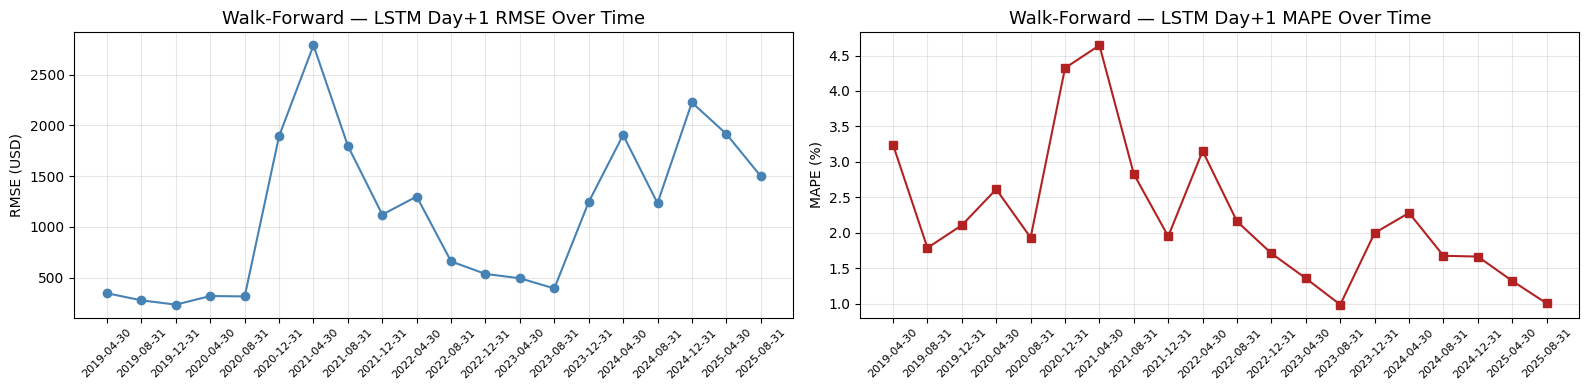


✅ Walk-forward complete. Avg RMSE: $1,125 | Avg MAPE: 2.24%


In [11]:
# ============================================================
# SECTION 7B: Walk-Forward Validation (OPTIONAL)
# ============================================================
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else"cpu")
class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, n_steps=1):
        super(LSTMAttentionModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_steps)   # ← multi-step output
        )

    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        attn_scores  = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context      = (lstm_out * attn_weights).sum(dim=1)
        return self.fc(context)

RUN_WALKFORWARD = True
if RUN_WALKFORWARD:
    print("🔄 Running Walk-Forward Validation (LSTM, monthly steps)...")
    INIT_TRAIN_MONTHS = 24
    STEP_MONTHS       = 4
    EVAL_MONTHS       = 1
    WF_EPOCHS         = 5

    dates       = df.index
    start_date  = dates[SEQ_LEN]
    fold_results = []

    init_cutoff = start_date + pd.DateOffset(months=INIT_TRAIN_MONTHS)
    step_starts = pd.date_range(init_cutoff, dates[-1], freq=f'{STEP_MONTHS}ME')

    wf_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _get_day1_price_from_scaled_log_returns(scaled_log_returns_arr, anchors_for_fold):
        """
        Inverse-scales the Day+1 log return and compounds with anchor price
        to get the predicted price for Day+1.
        """
        arr = np.array(scaled_log_returns_arr)
        if arr.ndim == 1:
            scaled_d1 = arr.reshape(-1, 1)
        else:
            scaled_d1 = arr[:, 0:1] # extract Day+1 scaled log return

        # Inverse-scale the log return using the global target_scaler
        unscaled_log_returns_d1 = target_scaler.inverse_transform(scaled_d1).ravel()

        # Reconstruct price using the anchor price
        price_d1 = anchors_for_fold * np.exp(unscaled_log_returns_d1)
        return price_d1

    for step_start in step_starts[:-1]:
        step_end = step_start + pd.DateOffset(months=EVAL_MONTHS)
        if step_end > dates[-1]:
            break

        df_idx  = df.index
        tr_mask = df_idx[SEQ_LEN:SEQ_LEN+len(X)] < step_start
        te_mask = ((df_idx[SEQ_LEN:SEQ_LEN+len(X)] >= step_start) &
                   (df_idx[SEQ_LEN:SEQ_LEN+len(X)] <  step_end))

        if tr_mask.sum() < 100 or te_mask.sum() < 5:
            continue

        X_tr = torch.tensor(X[tr_mask], dtype=torch.float32)
        y_tr = torch.tensor(y[tr_mask], dtype=torch.float32)
        X_te = torch.tensor(X[te_mask], dtype=torch.float32)
        y_te = y[te_mask]                   # keep as numpy for _get_day1_price_from_scaled_log_returns
        anchors_te = anchors[te_mask]       # Get anchors for this test fold

        tr_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=False)

        wf_model = LSTMAttentionModel(input_size=len(features)).to(wf_device)
        wf_opt   = torch.optim.Adam(wf_model.parameters(), lr=1e-3)
        wf_crit  = nn.MSELoss()

        wf_model.train()
        for _ in range(WF_EPOCHS):
            for Xb, yb in tr_loader:
                Xb, yb = Xb.to(wf_device), yb.to(wf_device)
                wf_opt.zero_grad()
                wf_crit(wf_model(Xb), yb).backward()
                wf_opt.step()

        wf_model.eval()
        with torch.no_grad():
            preds = wf_model(X_te.to(wf_device)).cpu().numpy()

        # ── Inverse-transform D+1 column only (no reshape ambiguity) ──────
        preds_d1  = _get_day1_price_from_scaled_log_returns(preds, anchors_te)
        actual_d1 = _get_day1_price_from_scaled_log_returns(y_te, anchors_te)

        if len(preds_d1) != len(actual_d1):
            print(f"   ⚠️  Shape mismatch after inv-transform "
                  f"({len(preds_d1)} vs {len(actual_d1)}), skipping fold.")
            continue

        rmse_d1 = float(np.sqrt(mean_squared_error(actual_d1, preds_d1)))
        mape_d1 = float(np.mean(np.abs((actual_d1 - preds_d1) / actual_d1)) * 100)
        fold_results.append({'period': str(step_start.date()), 'RMSE_D1': rmse_d1, 'MAPE_D1': mape_d1})
        print(f"   {step_start.date()} → RMSE Day+1: ${rmse_d1:,.0f}   MAPE: {mape_d1:.2f}%")

    if fold_results:
        wf_df = pd.DataFrame(fold_results)

        # Plot RMSE + MAPE side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))

        axes[0].plot(wf_df['period'], wf_df['RMSE_D1'], marker='o',
                     color='steelblue', linewidth=1.5)
        axes[0].set_title('Walk-Forward — LSTM Day+1 RMSE Over Time', fontsize=13)
        axes[0].set_ylabel('RMSE (USD)')
        axes[0].tick_params(axis='x', rotation=45, labelsize=8)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(wf_df['period'], wf_df['MAPE_D1'], marker='s',
                     color='firebrick', linewidth=1.5)
        axes[1].set_title('Walk-Forward — LSTM Day+1 MAPE Over Time', fontsize=13)
        axes[1].set_ylabel('MAPE (%)')
        axes[1].tick_params(axis='x', rotation=45, labelsize=8)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('walkforward_lstm.png', dpi=150)
        plt.show()
        print(f"\n✅ Walk-forward complete. Avg RMSE: ${wf_df['RMSE_D1'].mean():,.0f} | Avg MAPE: {wf_df['MAPE_D1'].mean():.2f}%")
    else:
        print("⚠️  No folds completed — check INIT_TRAIN_MONTHS vs dataset length.")

else:
    print("ℹ️  Walk-forward skipped (RUN_WALKFORWARD=False).")
    print("   Set RUN_WALKFORWARD=True above (~10 min on CPU).")
    print("   It retrains LSTM monthly on expanding data to show regime-aware performance.")


🔄 Running Walk-Forward Validation (TCN, monthly steps)...
   2019-04-30 → RMSE: $345   MAPE: 3.32%
   2019-08-31 → RMSE: $283   MAPE: 1.87%
   2019-12-31 → RMSE: $230   MAPE: 2.12%
   2020-04-30 → RMSE: $314   MAPE: 2.52%
   2020-08-31 → RMSE: $312   MAPE: 1.80%
   2020-12-31 → RMSE: $1,855   MAPE: 4.21%
   2021-04-30 → RMSE: $2,687   MAPE: 4.46%
   2021-08-31 → RMSE: $1,806   MAPE: 2.97%
   2021-12-31 → RMSE: $1,167   MAPE: 2.03%
   2022-04-30 → RMSE: $1,291   MAPE: 3.12%
   2022-08-31 → RMSE: $655   MAPE: 2.16%
   2022-12-31 → RMSE: $521   MAPE: 1.63%
   2023-04-30 → RMSE: $500   MAPE: 1.38%
   2023-08-31 → RMSE: $404   MAPE: 1.02%
   2023-12-31 → RMSE: $1,221   MAPE: 1.90%
   2024-04-30 → RMSE: $1,908   MAPE: 2.33%
   2024-08-31 → RMSE: $1,239   MAPE: 1.69%
   2024-12-31 → RMSE: $2,252   MAPE: 1.70%
   2025-04-30 → RMSE: $1,928   MAPE: 1.33%
   2025-08-31 → RMSE: $1,475   MAPE: 1.00%


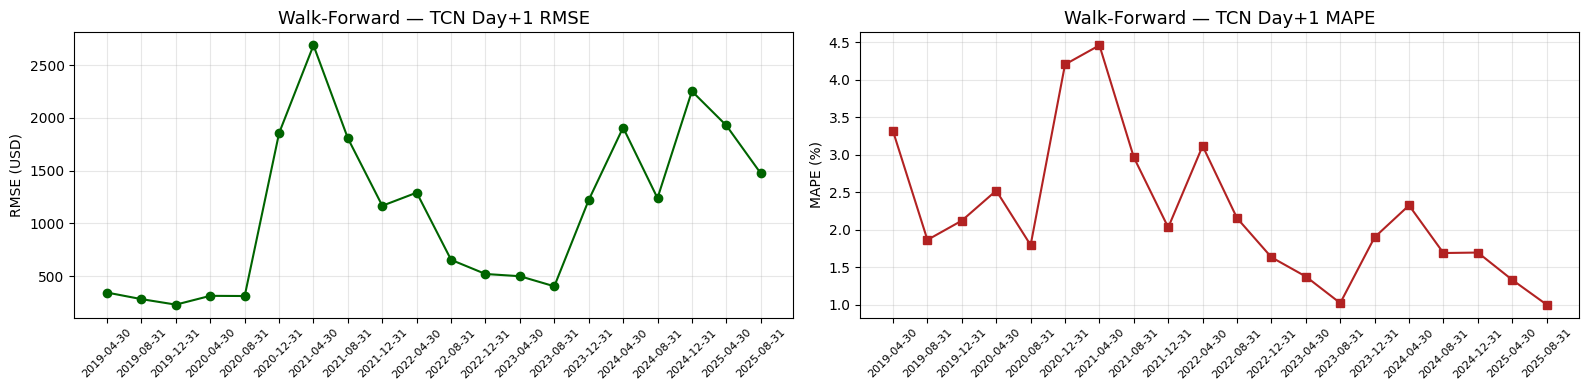


✅ TCN walk-forward complete.
   Avg RMSE: $1,120
   Avg MAPE: 2.23%


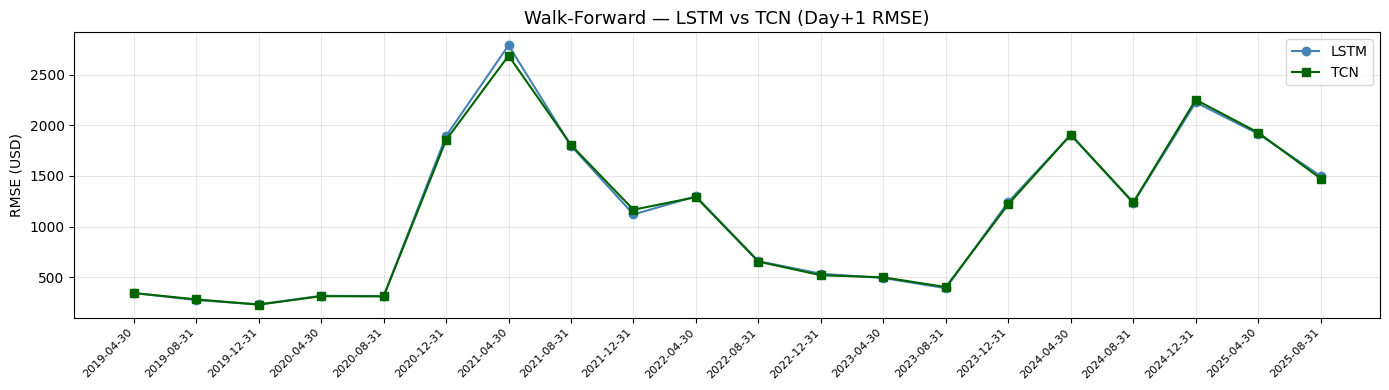

In [12]:
# ============================================================
# SECTION 7C: Walk-Forward Validation — TCN
# ============================================================

# TCN class definition (moved here to resolve NameError if SECTION 9C is not run first)
class Chomp1d(nn.Module):
    """Removes right-padding to enforce causality."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1  = nn.utils.weight_norm(
            nn.Conv1d(n_in, n_out, kernel_size, stride=stride,
                      padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1  = nn.ReLU()
        self.drop1  = nn.Dropout(dropout)

        self.conv2  = nn.utils.weight_norm(
            nn.Conv1d(n_out, n_out, kernel_size, stride=stride,
                      padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2  = nn.ReLU()
        self.drop2  = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1,
                                 self.conv2, self.chomp2, self.relu2, self.drop2)
        # 1x1 conv for residual when channel counts differ
        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.relu_out   = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu_out(out + res)

class TCN(nn.Module):
    def __init__(self, input_size, num_channels=(64, 64, 64, 64),
                 kernel_size=3, dropout=0.2, n_steps=1):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            in_ch    = input_size if i == 0 else num_channels[i - 1]
            padding  = (kernel_size - 1) * dilation
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size,
                                        stride=1, dilation=dilation,
                                        padding=padding, dropout=dropout))
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Sequential(
            nn.Linear(num_channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_steps)
        )

    def forward(self, x):
        # x: (batch, seq_len, features) → (batch, features, seq_len) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        x = x[:, :, -1]        # take last time step (causal)
        return self.fc(x)

RUN_WALKFORWARD_TCN = True
if RUN_WALKFORWARD_TCN:
    print("🔄 Running Walk-Forward Validation (TCN, monthly steps)...")
    INIT_TRAIN_MONTHS = 24
    STEP_MONTHS       = 4
    EVAL_MONTHS       = 1
    WF_EPOCHS         = 5

    dates        = df.index
    start_date   = dates[SEQ_LEN]
    fold_results_tcn = []

    init_cutoff = start_date + pd.DateOffset(months=INIT_TRAIN_MONTHS)
    step_starts = pd.date_range(init_cutoff, dates[-1], freq=f'{STEP_MONTHS}ME')

    wf_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _get_day1_price_from_scaled_log_returns(scaled_log_returns_arr, anchors_for_fold):
        """Inverse-scale Day+1 log return and compound with anchor price."""
        arr = np.array(scaled_log_returns_arr)
        scaled_d1 = arr.reshape(-1, 1) if arr.ndim == 1 else arr[:, 0:1]
        unscaled_log_returns_d1 = target_scaler.inverse_transform(scaled_d1).ravel()
        return anchors_for_fold * np.exp(unscaled_log_returns_d1)

    for step_start in step_starts[:-1]:
        step_end = step_start + pd.DateOffset(months=EVAL_MONTHS)
        if step_end > dates[-1]:
            break

        df_idx  = df.index
        tr_mask = df_idx[SEQ_LEN:SEQ_LEN+len(X)] < step_start
        te_mask = ((df_idx[SEQ_LEN:SEQ_LEN+len(X)] >= step_start) &
                   (df_idx[SEQ_LEN:SEQ_LEN+len(X)] <  step_end))

        if tr_mask.sum() < 100 or te_mask.sum() < 5:
            continue

        X_tr = torch.tensor(X[tr_mask], dtype=torch.float32)
        y_tr = torch.tensor(y[tr_mask], dtype=torch.float32)
        X_te = torch.tensor(X[te_mask], dtype=torch.float32)
        y_te = y[te_mask]
        anchors_te = anchors[te_mask]

        tr_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

        # ── TCN model + AdamW + Huber (matches main training config) ──
        wf_model = TCN(input_size=len(features), n_steps=N_STEPS).to(wf_device)
        wf_opt   = torch.optim.AdamW(wf_model.parameters(), lr=1e-3, weight_decay=1e-4)
        wf_crit  = nn.HuberLoss(delta=1.0)

        wf_model.train()
        for _ in range(WF_EPOCHS):
            for Xb, yb in tr_loader:
                Xb, yb = Xb.to(wf_device), yb.to(wf_device)
                wf_opt.zero_grad()
                loss = wf_crit(wf_model(Xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(wf_model.parameters(), 1.0)
                wf_opt.step()

        wf_model.eval()
        with torch.no_grad():
            preds = wf_model(X_te.to(wf_device)).cpu().numpy()

        preds_d1  = _get_day1_price_from_scaled_log_returns(preds, anchors_te)
        actual_d1 = _get_day1_price_from_scaled_log_returns(y_te, anchors_te)

        if len(preds_d1) != len(actual_d1):
            print(f"   ⚠️  Shape mismatch ({len(preds_d1)} vs {len(actual_d1)}), skipping fold.")
            continue

        rmse_d1 = float(np.sqrt(mean_squared_error(actual_d1, preds_d1)))
        mape_d1 = float(np.mean(np.abs((actual_d1 - preds_d1) / actual_d1)) * 100)
        fold_results_tcn.append({'period': str(step_start.date()),
                                 'RMSE_D1': rmse_d1, 'MAPE_D1': mape_d1})
        print(f"   {step_start.date()} → RMSE: ${rmse_d1:,.0f}   MAPE: {mape_d1:.2f}%")

    if fold_results_tcn:
        wf_tcn_df = pd.DataFrame(fold_results_tcn)

        # ── Plot RMSE + MAPE side-by-side ──
        fig, axes = plt.subplots(1, 2, figsize=(16, 4))

        axes[0].plot(wf_tcn_df['period'], wf_tcn_df['RMSE_D1'], marker='o',
                     color='darkgreen', linewidth=1.5)
        axes[0].set_title('Walk-Forward — TCN Day+1 RMSE', fontsize=13)
        axes[0].set_ylabel('RMSE (USD)')
        axes[0].tick_params(axis='x', rotation=45, labelsize=8)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(wf_tcn_df['period'], wf_tcn_df['MAPE_D1'], marker='s',
                     color='firebrick', linewidth=1.5)
        axes[1].set_title('Walk-Forward — TCN Day+1 MAPE', fontsize=13)
        axes[1].set_ylabel('MAPE (%)')
        axes[1].tick_params(axis='x', rotation=45, labelsize=8)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('walkforward_tcn.png', dpi=150)
        plt.show()

        print(f"\n✅ TCN walk-forward complete.")
        print(f"   Avg RMSE: ${wf_tcn_df['RMSE_D1'].mean():,.0f}")
        print(f"   Avg MAPE: {wf_tcn_df['MAPE_D1'].mean():.2f}%")

        # ── Optional: compare directly with LSTM walk-forward if available ──
        if 'wf_df' in globals() and len(wf_df) == len(wf_tcn_df):
            plt.figure(figsize=(14, 4))
            plt.plot(wf_df['period'],     wf_df['RMSE_D1'],
                     marker='o', label='LSTM', color='steelblue', linewidth=1.5)
            plt.plot(wf_tcn_df['period'], wf_tcn_df['RMSE_D1'],
                     marker='s', label='TCN',  color='darkgreen', linewidth=1.5)
            plt.title('Walk-Forward — LSTM vs TCN (Day+1 RMSE)', fontsize=13)
            plt.ylabel('RMSE (USD)')
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.legend(); plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('walkforward_lstm_vs_tcn.png', dpi=150)
            plt.show()
else:
    print("ℹ️  TCN walk-forward skipped.")

In [13]:
# ============================================================
# SECTION 8: Model 1 — DNN with Feature Attention Gate
# UPDATED: Output head now predicts N_STEPS prices simultaneously
# (Day+1, Day+2, Day+3) via nn.Linear(64, N_STEPS).
# Architecture: Attention Gate → Flatten → 512→256→128→64 → N_STEPS
# ============================================================

INPUT_DIM    = SEQ_LEN * len(features)
NUM_FEATURES = len(features)

class DeepNeuralNetwork(nn.Module):
    def __init__(self, input_dim, num_features, n_steps=1):
        super(DeepNeuralNetwork, self).__init__()

        self.feature_gate = nn.Sequential(
            nn.Linear(num_features, num_features),
            nn.ReLU(),
            nn.Linear(num_features, num_features),
            nn.Sigmoid()
        )

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_steps)   # ← multi-step output
        )

    def forward(self, x):
        gate = self.feature_gate(x.mean(dim=1))
        x    = x * gate.unsqueeze(1)
        return self.model(x)

dnn_model = DeepNeuralNetwork(INPUT_DIM, NUM_FEATURES, n_steps=N_STEPS)
print(f"✅ DNN + Feature Attention Gate (output: {N_STEPS} steps):")
print(dnn_model)
total_params = sum(p.numel() for p in dnn_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


✅ DNN + Feature Attention Gate (output: 3 steps):
DeepNeuralNetwork(
  (feature_gate): Sequential(
    (0): Linear(in_features=17, out_features=17, bias=True)
    (1): ReLU()
    (2): Linear(in_features=17, out_features=17, bias=True)
    (3): Sigmoid()
  )
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1020, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=128, out_features=64, b

In [14]:
# ============================================================
# SECTION 9: Model 2 — LSTM with Temporal Self-Attention
# UPDATED: Output head predicts N_STEPS prices simultaneously.
# Architecture: LSTM(2L) → Temporal Attention → FC → N_STEPS
# ============================================================

class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, n_steps=1):
        super(LSTMAttentionModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_steps)   # ← multi-step output
        )

    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        attn_scores  = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context      = (lstm_out * attn_weights).sum(dim=1)
        return self.fc(context)

lstm_model = LSTMAttentionModel(input_size=len(features), n_steps=N_STEPS)
print(f"✅ LSTM + Temporal Self-Attention (output: {N_STEPS} steps):")
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


✅ LSTM + Temporal Self-Attention (output: 3 steps):
LSTMAttentionModel(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total trainable parameters: 224,132


In [15]:
# ============================================================
# SECTION 9B: Model 3 — CNN-Transformer Hybrid
# UPDATED: Output head predicts N_STEPS prices simultaneously.
# Architecture: Conv1D→MaxPool→Conv1D → PosEnc
#               → TransformerEncoder(2L,8H) → GlobalAvgPool → N_STEPS
# ============================================================

class CNNTransformerModel(nn.Module):
    def __init__(self, input_size, seq_len, d_model=128, nhead=8,
                 num_tf_layers=2, dropout=0.3, n_steps=1):
        super(CNNTransformerModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64,
                      kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=64, out_channels=d_model,
                      kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        cnn_out_len = seq_len // 2
        self.pos_encoding = nn.Parameter(
            torch.randn(1, cnn_out_len, d_model) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_tf_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_steps)   # ← multi-step output
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = x + self.pos_encoding[:, :x.size(1), :]
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.fc(x)

cnn_transformer_model = CNNTransformerModel(
    input_size=len(features), seq_len=SEQ_LEN, n_steps=N_STEPS
)
print(f"✅ CNN-Transformer Hybrid (output: {N_STEPS} steps):")
print(cnn_transformer_model)
total_params = sum(p.numel() for p in cnn_transformer_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


✅ CNN-Transformer Hybrid (output: 3 steps):
CNNTransformerModel(
  (cnn): Sequential(
    (0): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128,

In [16]:
# ============================================================
# SECTION 9C (NEW): Model 4 — Temporal Convolutional Network
# ------------------------------------------------------------
# Based on Bai, Kolter & Koltun (2018) and Paper 2 (Jin et al, 2025).
# Dilated causal convolutions expand the receptive field
# exponentially with depth, giving access to long context
# without the vanishing-gradient problem of RNNs.
# ============================================================

class Chomp1d(nn.Module):
    """Removes right-padding to enforce causality."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1  = nn.utils.weight_norm(
            nn.Conv1d(n_in, n_out, kernel_size, stride=stride,
                      padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1  = nn.ReLU()
        self.drop1  = nn.Dropout(dropout)

        self.conv2  = nn.utils.weight_norm(
            nn.Conv1d(n_out, n_out, kernel_size, stride=stride,
                      padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2  = nn.ReLU()
        self.drop2  = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1,
                                 self.conv2, self.chomp2, self.relu2, self.drop2)
        # 1x1 conv for residual when channel counts differ
        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.relu_out   = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu_out(out + res)

class TCN(nn.Module):
    def __init__(self, input_size, num_channels=(64, 64, 64, 64),
                 kernel_size=3, dropout=0.2, n_steps=1):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            in_ch    = input_size if i == 0 else num_channels[i - 1]
            padding  = (kernel_size - 1) * dilation
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size,
                                        stride=1, dilation=dilation,
                                        padding=padding, dropout=dropout))
        self.tcn = nn.Sequential(*layers)
        self.fc  = nn.Sequential(
            nn.Linear(num_channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_steps)
        )

    def forward(self, x):
        # x: (batch, seq_len, features) → (batch, features, seq_len) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.tcn(x)
        x = x[:, :, -1]        # take last time step (causal)
        return self.fc(x)

tcn_model = TCN(input_size=len(features), n_steps=N_STEPS)
print(f"✅ TCN (dilated causal conv, output: {N_STEPS} steps):")
print(tcn_model)
total_params = sum(p.numel() for p in tcn_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

✅ TCN (dilated causal conv, output: 3 steps):
TCN(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (drop1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (drop2): Dropout(p=0.2, inplace=False)
      (net): Sequential(
        (0): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(17, 64, kernel_size=(1,), stride=(1,))
      (relu_out): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      

In [17]:
# ============================================================
# SECTION 10 (REVISED): Training with AdamW + Huber Loss
# ------------------------------------------------------------
# AdamW = Adam with decoupled weight decay (better regularization).
# Huber loss is quadratic near zero, linear far from it,
# so large price-shock residuals do not dominate the gradient.
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3,
                patience=15, loss_type='huber', huber_delta=1.0):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    if loss_type == 'huber':
        criterion = nn.HuberLoss(delta=huber_delta)
    elif loss_type == 'mae':
        criterion = nn.L1Loss()
    else:
        criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val, best_weights, patience_counter = float('inf'), None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += criterion(model(X_batch), y_batch).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        scheduler.step()
        train_losses.append(train_loss); val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"Epoch [{epoch:3d}/{epochs}] | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val:
            best_val = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"   Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(best_weights)
    return train_losses, val_losses

Using device: cuda


✅ All models moved to cuda
Training DNN Model...
Epoch [ 10/100] | Train: 0.313489 | Val: 0.207634 | LR: 9.76e-04
   Early stopping at epoch 16.

Training LSTM Model...
Epoch [ 10/100] | Train: 0.345605 | Val: 0.194022 | LR: 9.76e-04
Epoch [ 20/100] | Train: 0.345963 | Val: 0.194476 | LR: 9.05e-04
   Early stopping at epoch 20.

Training CNN-Transformer Model...
Epoch [ 10/100] | Train: 0.346607 | Val: 0.195037 | LR: 9.76e-04
Epoch [ 20/100] | Train: 0.343701 | Val: 0.204461 | LR: 9.05e-04
   Early stopping at epoch 27.

Training TCN Model...
Epoch [ 10/100] | Train: 0.336404 | Val: 0.194684 | LR: 9.76e-04
Epoch [ 20/100] | Train: 0.296117 | Val: 0.204103 | LR: 9.05e-04
   Early stopping at epoch 27.


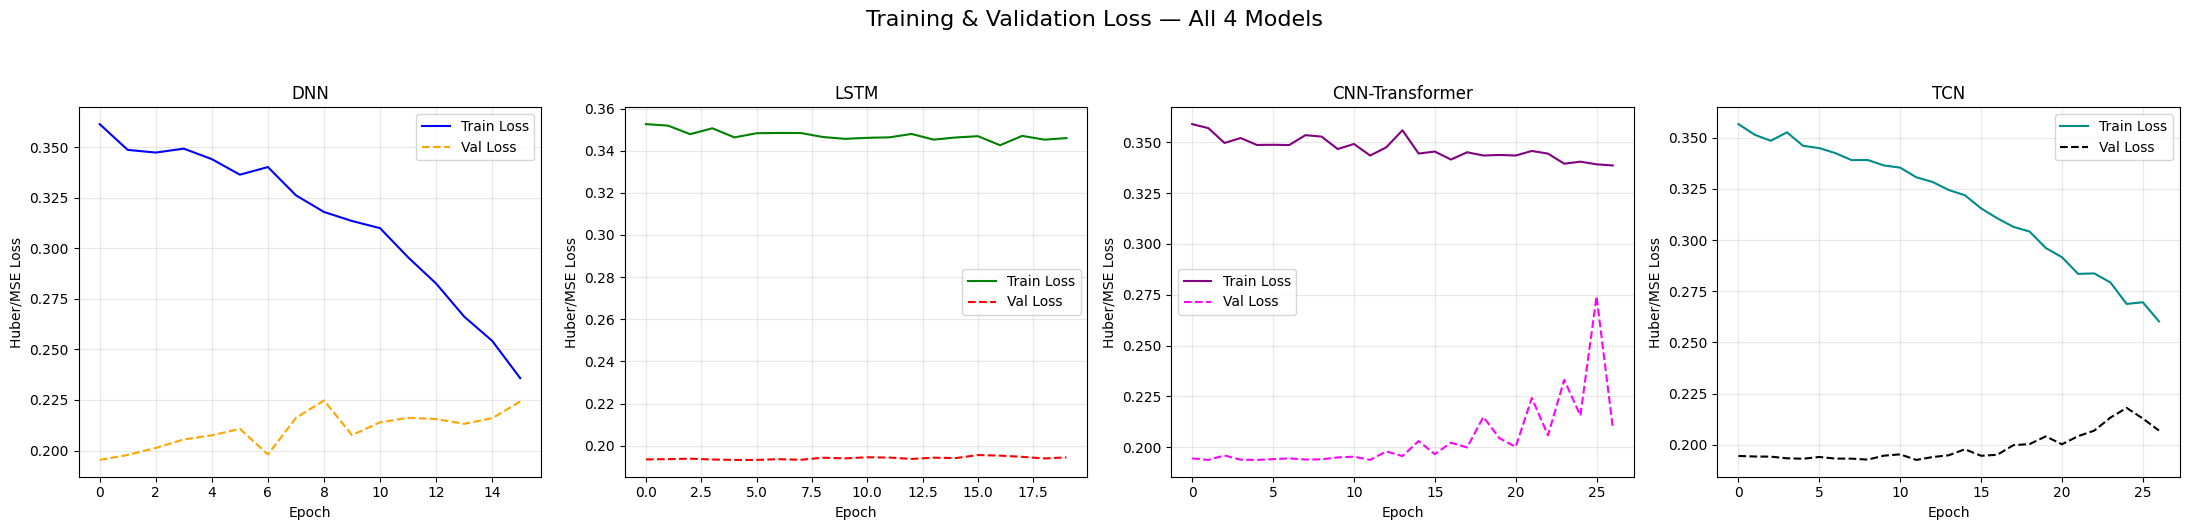

In [18]:
# ============================================================
# SECTION 11: Train All 4 Models & Plot Loss Curves
# ============================================================

# Ensure all models are on the correct device
dnn_model = dnn_model.to(device)
lstm_model = lstm_model.to(device)
cnn_transformer_model = cnn_transformer_model.to(device)
tcn_model = tcn_model.to(device)
print(f"✅ All models moved to {device}")

print("=" * 50)
print("Training DNN Model...")
print("=" * 50)
dnn_train_losses, dnn_val_losses = train_model(dnn_model, train_loader, val_loader, epochs=100)

print("\n" + "=" * 50)
print("Training LSTM Model...")
print("=" * 50)
lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, epochs=100)

print("\n" + "=" * 50)
print("Training CNN-Transformer Model...")
print("=" * 50)
cnn_trans_train_losses, cnn_trans_val_losses = train_model(cnn_transformer_model, train_loader, val_loader, epochs=100)

print("\n" + "=" * 50)
print("Training TCN Model...")
print("=" * 50)
tcn_train_losses, tcn_val_losses = train_model(tcn_model, train_loader, val_loader, epochs=100)

# --- Plot all 4 loss curves side by side ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

model_data = [
    (dnn_train_losses, dnn_val_losses, 'DNN', ('blue', 'orange')),
    (lstm_train_losses, lstm_val_losses, 'LSTM', ('green', 'red')),
    (cnn_trans_train_losses, cnn_trans_val_losses, 'CNN-Transformer', ('purple', 'magenta')),
    (tcn_train_losses, tcn_val_losses, 'TCN', ('darkcyan', 'black'))
]

for ax, (tr_loss, val_loss, title, colors) in zip(axes, model_data):
    ax.plot(tr_loss, label='Train Loss', color=colors[0], linewidth=1.5)
    ax.plot(val_loss, label='Val Loss', color=colors[1], linewidth=1.5, linestyle='--')
    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Huber/MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss — All 4 Models', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('loss_curves_all_4.png', dpi=150)
plt.show()

In [19]:
# ============================================================
# SECTION 12 (REVISED): Comprehensive Evaluation
# ------------------------------------------------------------
# Reconstructs predicted PRICES from predicted LOG RETURNS,
# computes the full metric suite, and compares each model
# against a naive random-walk baseline (price_{t+1} = price_t).
# ============================================================
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, confusion_matrix,
                              precision_score, recall_score, f1_score)

def reconstruct_prices(scaled_preds, anchors, n_steps):
    """Convert scaled log-return predictions back to USD prices."""
    # Inverse-scale returns, then compound on each anchor price
    preds_flat      = scaled_preds.reshape(-1, 1)
    log_returns_hat = target_scaler.inverse_transform(preds_flat).reshape(-1, n_steps)
    price_preds = np.zeros_like(log_returns_hat)
    for h in range(n_steps):
        if h == 0:
            price_preds[:, 0] = anchors * np.exp(log_returns_hat[:, 0])
        else:
            price_preds[:, h] = price_preds[:, h-1] * np.exp(log_returns_hat[:, h])
    return price_preds

def directional_metrics(actual_prices, pred_prices, anchor_prices):
    """
    Up-move classification: direction of change relative to anchor.
    y_true = 1 if actual > anchor else 0
    y_pred = 1 if predicted > anchor else 0
    """
    y_true = (actual_prices > anchor_prices).astype(int)
    y_pred = (pred_prices   > anchor_prices).astype(int)
    da     = (y_true == y_pred).mean()
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score   (y_true, y_pred, zero_division=0)
    f1     = f1_score       (y_true, y_pred, zero_division=0)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return da, prec, rec, f1, cm

def evaluate_model_full(model, X_test_t, anchors_test, y_test_scaled, label="Model"):
    model.eval()
    with torch.no_grad():
        scaled_preds = model(X_test_t.to(device)).cpu().numpy()

    pred_prices   = reconstruct_prices(scaled_preds, anchors_test, N_STEPS)
    actual_prices = reconstruct_prices(y_test_scaled, anchors_test, N_STEPS)

    print(f"\n{'='*62}")
    print(f" {label} — Full Evaluation")
    print(f"{'='*62}")
    print(f"{'Horizon':<8} {'RMSE':>10} {'MAE':>10} {'MAPE%':>8} {'R²':>8} {'DirAcc':>8} {'F1(up)':>8}")
    print('-' * 62)

    results = {}
    for h in range(N_STEPS):
        a, p, anc = actual_prices[:, h], pred_prices[:, h], anchors_test
        rmse  = np.sqrt(mean_squared_error(a, p))
        mae   = mean_absolute_error(a, p)
        mape  = np.mean(np.abs((a - p) / a)) * 100
        r2    = r2_score(a, p)
        da, prec, rec, f1, cm = directional_metrics(a, p, anc)
        print(f"Day+{h+1:<4} ${rmse:>9,.0f} ${mae:>9,.0f} {mape:>7.3f} {r2:>8.4f} {da:>7.3f} {f1:>7.3f}")
        results[f'day_{h+1}'] = dict(rmse=rmse, mae=mae, mape=mape,
                                     r2=r2, da=da, precision=prec,
                                     recall=rec, f1=f1, cm=cm,
                                     actual=a, predicted=p)
    return results

# ---- Naive random-walk baseline: y_pred = anchor (today's price) ----
def evaluate_naive_baseline(anchors_test, y_test_scaled):
    actual_prices = reconstruct_prices(y_test_scaled, anchors_test, N_STEPS)
    print(f"\n{'='*62}")
    print(f" NAIVE RANDOM-WALK BASELINE (y_pred = today's price)")
    print(f"{'='*62}")
    print(f"{'Horizon':<8} {'RMSE':>10} {'MAE':>10} {'MAPE%':>8} {'R²':>8} {'DirAcc':>8}")
    print('-' * 62)
    baseline = {}
    for h in range(N_STEPS):
        a = actual_prices[:, h]
        p = anchors_test                # naive: always predict today's price
        rmse = np.sqrt(mean_squared_error(a, p))
        mae  = mean_absolute_error(a, p)
        mape = np.mean(np.abs((a - p) / a)) * 100
        r2   = r2_score(a, p)
        da   = (a > anchors_test).astype(int).mean()   # 50/50-ish expected
        print(f"Day+{h+1:<4} ${rmse:>9,.0f} ${mae:>9,.0f} {mape:>7.3f} {r2:>8.4f} {da:>7.3f}")
        baseline[f'day_{h+1}'] = dict(rmse=rmse, mae=mae, mape=mape, r2=r2)
    return baseline

# ---- Run everything ----
baseline_res = evaluate_naive_baseline(anchors_test, y_test)
dnn_res      = evaluate_model_full(dnn_model,            X_test_t, anchors_test, y_test, "DNN")
lstm_res     = evaluate_model_full(lstm_model,           X_test_t, anchors_test, y_test, "LSTM")
cnn_tr_res   = evaluate_model_full(cnn_transformer_model,X_test_t, anchors_test, y_test, "CNN-Transformer")
tcn_res      = evaluate_model_full(tcn_model,            X_test_t, anchors_test, y_test, "TCN")


 NAIVE RANDOM-WALK BASELINE (y_pred = today's price)
Horizon        RMSE        MAE    MAPE%       R²   DirAcc
--------------------------------------------------------------
Day+1    $    2,143 $    1,549   1.676   0.9809   0.495
Day+2    $    2,945 $    2,218   2.394   0.9640   0.497
Day+3    $    3,527 $    2,707   2.921   0.9484   0.521

 DNN — Full Evaluation
Horizon        RMSE        MAE    MAPE%       R²   DirAcc   F1(up)
--------------------------------------------------------------
Day+1    $    2,149 $    1,556   1.683   0.9808   0.495   0.264
Day+2    $    2,952 $    2,238   2.413   0.9638   0.495   0.177
Day+3    $    3,540 $    2,750   2.965   0.9481   0.473   0.155

 LSTM — Full Evaluation
Horizon        RMSE        MAE    MAPE%       R²   DirAcc   F1(up)
--------------------------------------------------------------
Day+1    $    2,149 $    1,560   1.688   0.9808   0.517   0.599
Day+2    $    2,963 $    2,249   2.426   0.9635   0.495   0.559
Day+3    $    3,550 $    2,7

In [20]:
# ============================================================
# SECTION 12B (NEW): Ensemble — Score-Average and Weighted-by-Validation
# ------------------------------------------------------------
# Inspired by Combinatorial Fusion Analysis (Paper 1) but
# WITHOUT their per-day oracle selection — weights are locked
# in using VALIDATION performance only.
# ============================================================

def get_predictions(model, X_t):
    model.eval()
    with torch.no_grad():
        return model(X_t.to(device)).cpu().numpy()

# Collect scaled predictions on VAL (to compute weights) and TEST (to evaluate)
models_dict = {
    'DNN': dnn_model,
    'LSTM': lstm_model,
    'CNN-Transformer': cnn_transformer_model,
    'TCN': tcn_model,
}

val_preds_scaled  = {k: get_predictions(m, X_val_t)  for k, m in models_dict.items()}
test_preds_scaled = {k: get_predictions(m, X_test_t) for k, m in models_dict.items()}

# --- Weights from VALIDATION MAPE (Day+1), not test ---
val_actual_prices = reconstruct_prices(y_val, anchors_val, N_STEPS)
weights = {}
for name, sp in val_preds_scaled.items():
    val_pred_prices = reconstruct_prices(sp, anchors_val, N_STEPS)
    val_mape = np.mean(np.abs((val_actual_prices[:, 0] - val_pred_prices[:, 0])
                              / val_actual_prices[:, 0]))
    weights[name] = 1.0 / (val_mape + 1e-8)          # inverse-MAPE weighting

w_sum = sum(weights.values())
weights = {k: v / w_sum for k, v in weights.items()}
print("\nValidation-based ensemble weights:")
for k, v in weights.items():
    print(f"   {k:<18} {v:.4f}")

# --- Ensemble predictions on TEST set ---
simple_avg  = np.mean([test_preds_scaled[k] for k in models_dict], axis=0)
weighted    = np.sum([weights[k] * test_preds_scaled[k] for k in models_dict], axis=0)

def eval_ensemble(scaled_preds, label):
    pred_prices   = reconstruct_prices(scaled_preds, anchors_test, N_STEPS)
    actual_prices = reconstruct_prices(y_test, anchors_test, N_STEPS)
    print(f"\n{label}")
    print(f"{'Horizon':<8} {'RMSE':>10} {'MAE':>10} {'MAPE%':>8} {'R²':>8} {'DirAcc':>8} {'F1(up)':>8}")
    out = {}
    for h in range(N_STEPS):
        a, p, anc = actual_prices[:, h], pred_prices[:, h], anchors_test
        rmse, mae = np.sqrt(mean_squared_error(a,p)), mean_absolute_error(a,p)
        mape = np.mean(np.abs((a-p)/a))*100
        r2   = r2_score(a, p)
        da, prec, rec, f1, _ = directional_metrics(a, p, anc)
        print(f"Day+{h+1:<4} ${rmse:>9,.0f} ${mae:>9,.0f} {mape:>7.3f} {r2:>8.4f} {da:>7.3f} {f1:>7.3f}")
        out[f'day_{h+1}'] = dict(rmse=rmse, mae=mae, mape=mape, r2=r2, da=da, f1=f1)
    return out

ens_avg_res = eval_ensemble(simple_avg, "ENSEMBLE — Simple Average")
ens_w_res   = eval_ensemble(weighted,   "ENSEMBLE — Weighted by Validation MAPE")


Validation-based ensemble weights:
   DNN                0.2488
   LSTM               0.2509
   CNN-Transformer    0.2493
   TCN                0.2509

ENSEMBLE — Simple Average
Horizon        RMSE        MAE    MAPE%       R²   DirAcc   F1(up)
Day+1    $    2,137 $    1,550   1.676   0.9810   0.525   0.560
Day+2    $    2,945 $    2,232   2.407   0.9640   0.481   0.531
Day+3    $    3,529 $    2,705   2.919   0.9484   0.517   0.570

ENSEMBLE — Weighted by Validation MAPE
Horizon        RMSE        MAE    MAPE%       R²   DirAcc   F1(up)
Day+1    $    2,137 $    1,550   1.676   0.9810   0.521   0.554
Day+2    $    2,945 $    2,232   2.407   0.9640   0.481   0.531
Day+3    $    3,529 $    2,705   2.919   0.9484   0.515   0.567


Epoch [ 10/40] | Train: 0.330453 | Val: 0.195020 | LR: 8.54e-04
   Early stopping at epoch 14.

Full-feature MAPE (Day+1): 1.688%

Epoch [ 10/40] | Train: 0.334769 | Val: 0.194706 | LR: 8.54e-04
   Early stopping at epoch 19.
Drop technical    → MAPE 1.715%  (Δ = +0.027)
Epoch [ 10/40] | Train: 0.332881 | Val: 0.195016 | LR: 8.54e-04
   Early stopping at epoch 16.
Drop sentiment    → MAPE 1.673%  (Δ = -0.015)
Epoch [ 10/40] | Train: 0.341046 | Val: 0.194750 | LR: 8.54e-04
   Early stopping at epoch 17.
Drop cross_asset  → MAPE 1.682%  (Δ = -0.006)
Epoch [ 10/40] | Train: 0.333134 | Val: 0.193827 | LR: 8.54e-04
   Early stopping at epoch 19.
Drop macro        → MAPE 1.757%  (Δ = +0.069)


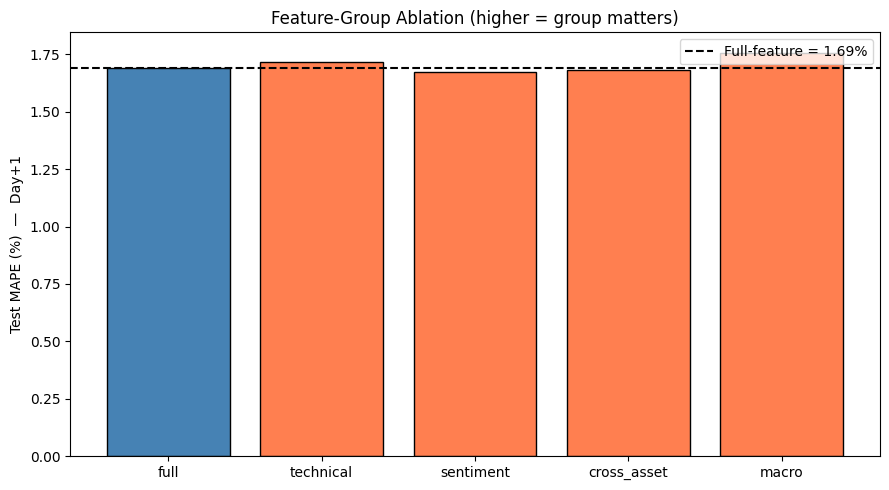

In [21]:
# ============================================================
# SECTION 13 (NEW): Feature-Group Ablation Study
# ------------------------------------------------------------
# Trains the best model once per "dropped group" and measures
# the delta in test MAPE. This isolates the contribution of
# each data source — a novel analysis for your paper.
# ============================================================

FEATURE_GROUPS = {
    'technical' : ['LogReturn','LogVolume','Close_SMA30','Close_EMA14',
                   'MACD_norm','RSI_14','BB_Width','Halving_sin','Halving_cos'],
    'sentiment' : ['Fear_Greed'],
    'cross_asset': ['ETH_Return','SP500_Return','VIX','Gold_Return','Oil_Return'],
    'macro'     : ['FedFunds','CPI_YoY'],
}

def run_ablation(drop_group=None, epochs=40):
    kept = [f for f in features
            if f not in (FEATURE_GROUPS.get(drop_group, []))]
    kept_idx = [features.index(f) for f in kept]
    X_tr = X_train_t[:, :, kept_idx]
    X_va = X_val_t  [:, :, kept_idx]
    X_te = X_test_t [:, :, kept_idx]

    loader_tr = DataLoader(TensorDataset(X_tr, y_train_t), batch_size=64, shuffle=True)
    loader_va = DataLoader(TensorDataset(X_va, y_val_t),   batch_size=64, shuffle=False)

    model = TCN(input_size=len(kept), n_steps=N_STEPS)
    train_model(model, loader_tr, loader_va, epochs=epochs, patience=10)

    with torch.no_grad():
        preds = model(X_te.to(device)).cpu().numpy()
    pp = reconstruct_prices(preds, anchors_test, N_STEPS)
    ap = reconstruct_prices(y_test, anchors_test, N_STEPS)
    mape = np.mean(np.abs((ap[:,0] - pp[:,0]) / ap[:,0])) * 100
    return mape

baseline_mape = run_ablation(drop_group=None)
print(f"\nFull-feature MAPE (Day+1): {baseline_mape:.3f}%\n")

ablation_results = {'full': baseline_mape}
for grp in FEATURE_GROUPS:
    m = run_ablation(drop_group=grp)
    delta = m - baseline_mape
    print(f"Drop {grp:<12} → MAPE {m:.3f}%  (Δ = {delta:+.3f})")
    ablation_results[grp] = m

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
names = list(ablation_results.keys())
vals  = [ablation_results[k] for k in names]
ax.bar(names, vals, color=['steelblue'] + ['coral']*4, edgecolor='black')
ax.axhline(baseline_mape, linestyle='--', color='black', label=f'Full-feature = {baseline_mape:.2f}%')
ax.set_ylabel('Test MAPE (%)  —  Day+1')
ax.set_title('Feature-Group Ablation (higher = group matters)')
ax.legend(); plt.tight_layout(); plt.savefig('ablation.png', dpi=150); plt.show()

In [22]:
# ============================================================
# SECTION 14 (NEW): Diebold–Mariano Pairwise Significance
# ------------------------------------------------------------
# Tests whether the difference in forecast accuracy between
# two models is statistically significant.
# ============================================================
from scipy.stats import norm

def diebold_mariano(errors_a, errors_b, h=1):
    """
    errors_a, errors_b: arrays of forecast errors (actual - predicted)
    h: forecast horizon (days ahead), used for HAC variance
    Returns (DM statistic, two-sided p-value).
    Negative DM  ⇒ model A better.  Positive DM ⇒ model B better.
    """
    d   = errors_a**2 - errors_b**2        # loss differential (squared-error loss)
    T   = len(d)
    mu  = d.mean()
    # Newey-West variance with lag = h-1
    gamma0 = np.var(d, ddof=0)
    var_d  = gamma0
    for k in range(1, h):
        cov_k = np.cov(d[k:], d[:-k], ddof=0)[0, 1]
        var_d += 2 * (1 - k/h) * cov_k
    dm  = mu / np.sqrt(var_d / T)
    p   = 2 * (1 - norm.cdf(abs(dm)))
    return dm, p

# Build error dict for Day+1
all_models = {
    'DNN'            : dnn_res['day_1'],
    'LSTM'           : lstm_res['day_1'],
    'CNN-Transformer': cnn_tr_res['day_1'],
    'TCN'            : tcn_res['day_1'],
    'Ensemble-Avg'   : ens_avg_res['day_1'],
    'Ensemble-Wted'  : ens_w_res['day_1'],
}
# We need the error series — reconstruct from stored actual/predicted
errors = {}
for name, d in all_models.items():
    if 'actual' in d:
        errors[name] = d['actual'] - d['predicted']
    else:
        # Ensembles: recompute
        sp = simple_avg if 'Avg' in name else weighted
        pp = reconstruct_prices(sp, anchors_test, N_STEPS)[:, 0]
        ap = reconstruct_prices(y_test, anchors_test, N_STEPS)[:, 0]
        errors[name] = ap - pp

print("\nDiebold–Mariano pairwise test (Day+1 squared-error loss):")
print(f"{'':<18} " + " ".join(f"{n:>16}" for n in errors))
for a in errors:
    row = [f"{a:<18}"]
    for b in errors:
        if a == b:
            row.append(f"{'—':>16}")
        else:
            dm, p = diebold_mariano(errors[a], errors[b])
            sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
            row.append(f"{dm:>+6.2f} (p={p:.3f}){sig:<3}")
    print(" ".join(row))


Diebold–Mariano pairwise test (Day+1 squared-error loss):
                                DNN             LSTM  CNN-Transformer              TCN     Ensemble-Avg    Ensemble-Wted
DNN                               —  +0.03 (p=0.976)     -2.72 (p=0.006)***  -0.91 (p=0.365)     +1.13 (p=0.260)     +1.13 (p=0.259)   
LSTM                -0.03 (p=0.976)                   —  -4.23 (p=0.000)***  -0.82 (p=0.415)     +1.54 (p=0.124)     +1.54 (p=0.124)   
CNN-Transformer     +2.72 (p=0.006)***  +4.23 (p=0.000)***                —  +1.15 (p=0.252)     +4.04 (p=0.000)***  +4.04 (p=0.000)***
TCN                 +0.91 (p=0.365)     +0.82 (p=0.415)     -1.15 (p=0.252)                   —  +1.51 (p=0.132)     +1.51 (p=0.131)   
Ensemble-Avg        -1.13 (p=0.260)     -1.54 (p=0.124)     -4.04 (p=0.000)***  -1.51 (p=0.132)                   —  +1.51 (p=0.131)   
Ensemble-Wted       -1.13 (p=0.259)     -1.54 (p=0.124)     -4.04 (p=0.000)***  -1.51 (p=0.131)     -1.51 (p=0.131)                   —


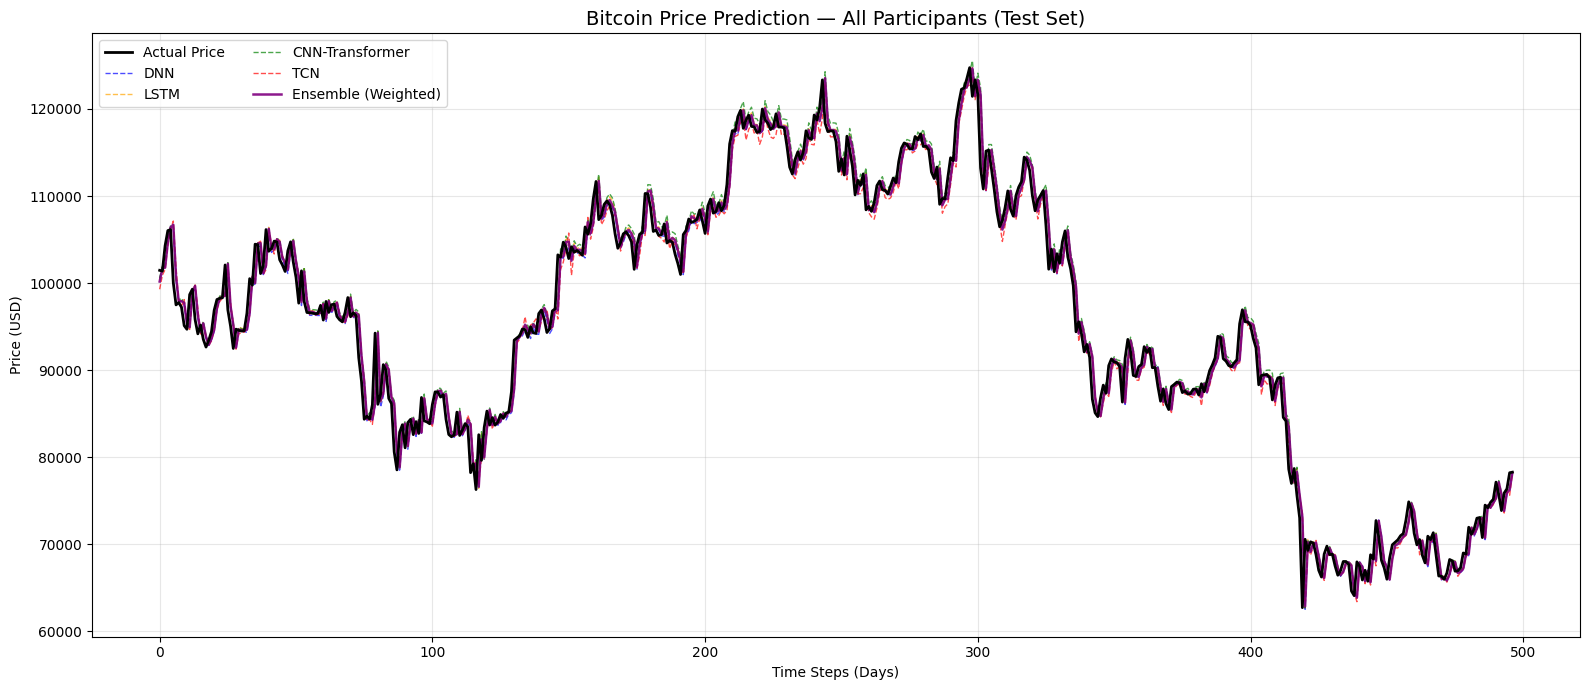

In [23]:
# ============================================================
# SECTION 15: Visualize Predictions vs Actual Prices
# ------------------------------------------------------------
# Comparing all 4 base models and the Weighted Ensemble
# against the actual Bitcoin price for the test set.
# ============================================================

plt.figure(figsize=(16, 7))

# Reconstruct actual prices
actual_prices = reconstruct_prices(y_test, anchors_test, N_STEPS)[:, 0]

# Helper to get and reconstruct predictions
def get_p(model):
    model.eval()
    with torch.no_grad():
        scaled = model(X_test_t.to(device)).cpu().numpy()
    return reconstruct_prices(scaled, anchors_test, N_STEPS)[:, 0]

# Plot Actual
plt.plot(actual_prices, label='Actual Price', color='black', linewidth=2.0, zorder=3)

# Plot Base Models
plt.plot(get_p(dnn_model), label='DNN', color='blue', linewidth=1.0, linestyle='--', alpha=0.7)
plt.plot(get_p(lstm_model), label='LSTM', color='orange', linewidth=1.0, linestyle='--', alpha=0.7)
plt.plot(get_p(cnn_transformer_model), label='CNN-Transformer', color='green', linewidth=1.0, linestyle='--', alpha=0.7)
plt.plot(get_p(tcn_model), label='TCN', color='red', linewidth=1.0, linestyle='--', alpha=0.7)

# Plot Ensemble
ensemble_prices = reconstruct_prices(weighted, anchors_test, N_STEPS)[:, 0]
plt.plot(ensemble_prices, label='Ensemble (Weighted)', color='purple', linewidth=1.8, alpha=0.9)

plt.title('Bitcoin Price Prediction — All Participants (Test Set)', fontsize=14)
plt.xlabel('Time Steps (Days)')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_comprehensive.png', dpi=150)
plt.show()


📊 Model Comparison Summary (Day+1):
          Model  RMSE ($)  MAE ($)     R²
            DNN   2149.35  1555.61 0.9808
           LSTM   2148.97  1560.30 0.9808
CNN-Transformer   2225.02  1630.81 0.9794
            TCN   2174.65  1615.71 0.9803


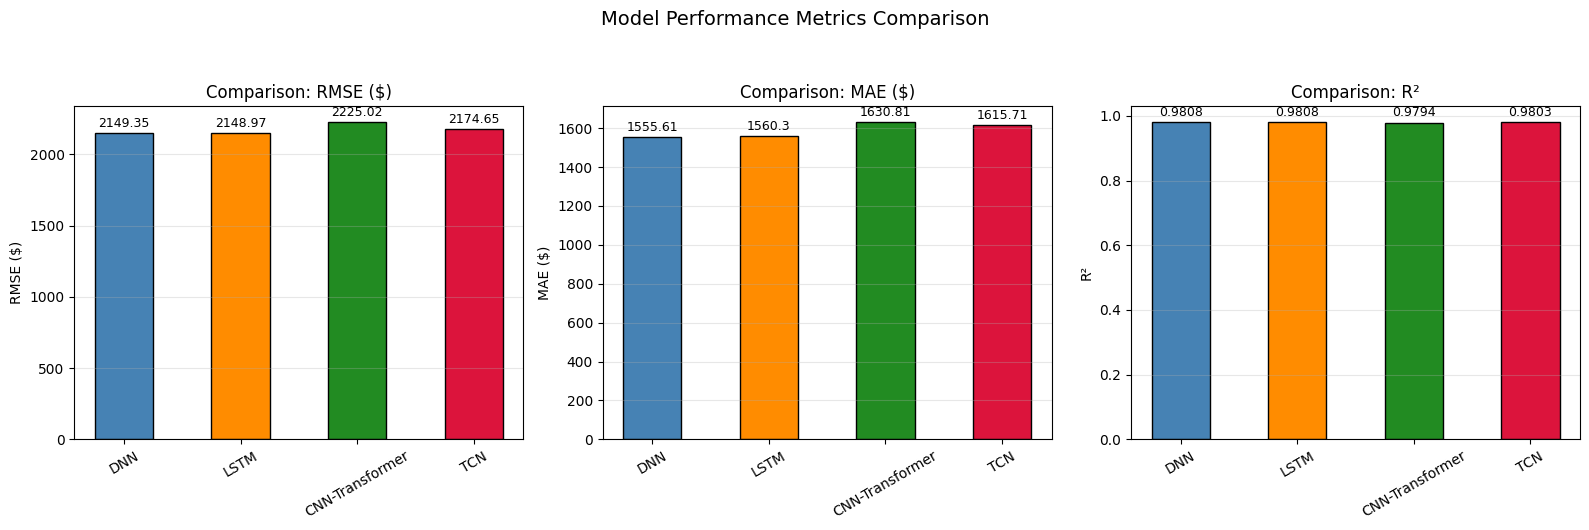

In [24]:
# ============================================================
# SECTION 16: Model Comparison Summary
# What it does: Builds a clear comparison table and bar chart
# summarizing the performance of DNN vs LSTM across all three
# evaluation metrics. Helps determine which model performs better.
# ============================================================

# Extracting Day+1 metrics from the result dictionaries created in Section 12
results = pd.DataFrame({
    'Model': ['DNN', 'LSTM', 'CNN-Transformer', 'TCN'],
    'RMSE ($)': [
        round(dnn_res['day_1']['rmse'], 2),
        round(lstm_res['day_1']['rmse'], 2),
        round(cnn_tr_res['day_1']['rmse'], 2),
        round(tcn_res['day_1']['rmse'], 2)
    ],
    'MAE ($)': [
        round(dnn_res['day_1']['mae'], 2),
        round(lstm_res['day_1']['mae'], 2),
        round(cnn_tr_res['day_1']['mae'], 2),
        round(tcn_res['day_1']['mae'], 2)
    ],
    'R²': [
        round(dnn_res['day_1']['r2'], 4),
        round(lstm_res['day_1']['r2'], 4),
        round(cnn_tr_res['day_1']['r2'], 4),
        round(tcn_res['day_1']['r2'], 4)
    ]
})

print("\n📊 Model Comparison Summary (Day+1):")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

for ax, metric in zip(axes, ['RMSE ($)', 'MAE ($)', 'R²']):
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'Comparison: {metric}', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Metrics Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('model_comparison_fixed.png', dpi=150)
plt.show()


📊 Final Model Comparison (Day+1):


,Model,RMSE ($),MAE ($),R²,DirAcc
5,Ens-Wtd,2137.02,1549.77,0.9810,0.521
4,Ens-Avg,2137.07,1549.79,0.9810,0.525
1,LSTM,2148.97,1560.30,0.9808,0.517
0,DNN,2149.35,1555.61,0.9808,0.495
3,TCN,2174.65,1615.71,0.9803,0.527
2,CNN-Trans,2225.02,1630.81,0.9794,0.509


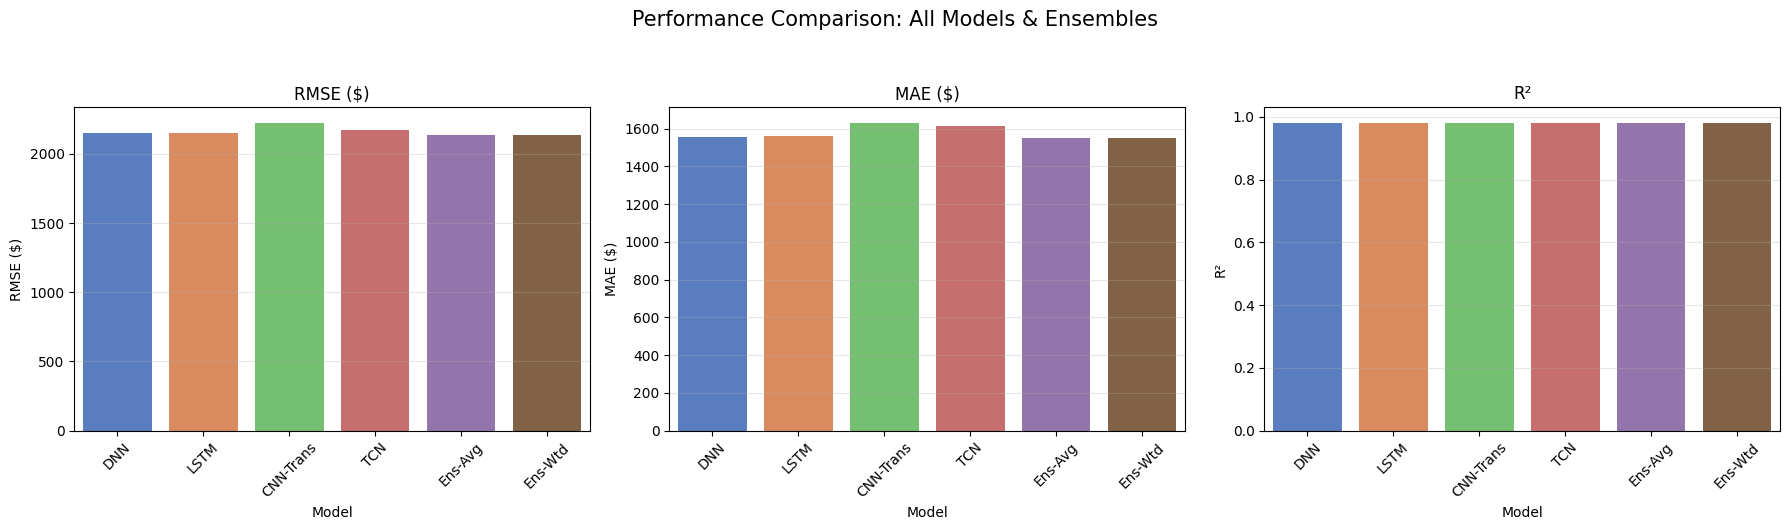

In [25]:
# ============================================================
# SECTION 16B: Comprehensive Multi-Model Comparison Summary
# What it does: Produces a complete comparison table and bar
# charts for all base models and ensembles.
# ============================================================

all_results_data = []

# Helper to extract metrics for Day+1 from result dicts
def get_metrics(res_dict, name):
    d1 = res_dict['day_1']
    return {
        'Model': name,
        'RMSE ($)': round(float(d1['rmse']), 2),
        'MAE ($)':  round(float(d1['mae']), 2),
        'R²':       round(float(d1['r2']), 4),
        'DirAcc':   round(float(d1['da']), 3)
    }

# Populate results list
all_results_data.append(get_metrics(dnn_res, 'DNN'))
all_results_data.append(get_metrics(lstm_res, 'LSTM'))
all_results_data.append(get_metrics(cnn_tr_res, 'CNN-Trans'))
all_results_data.append(get_metrics(tcn_res, 'TCN'))
all_results_data.append(get_metrics(ens_avg_res, 'Ens-Avg'))
all_results_data.append(get_metrics(ens_w_res, 'Ens-Wtd'))

results_df = pd.DataFrame(all_results_data)

print("\n📊 Final Model Comparison (Day+1):")
display(results_df.sort_values('RMSE ($)'))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('viridis', len(results_df))

for ax, metric in zip(axes, ['RMSE ($)', 'MAE ($)', 'R²']):
    sns.barplot(x='Model', y=metric, data=results_df, ax=ax, palette='muted', hue='Model', legend=False)
    ax.set_title(f'{metric}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Performance Comparison: All Models & Ensembles', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150)
plt.show()

In [26]:
# ============================================================
# SECTION 17: Save Models
# What it does: Saves the trained model weights to disk using
# PyTorch's state_dict format. These can be loaded later for
# inference without retraining.
# ============================================================

torch.save(dnn_model.state_dict(),  'dnn_bitcoin_model.pth')
torch.save(lstm_model.state_dict(), 'lstm_bitcoin_model.pth')
torch.save(cnn_transformer_model.state_dict(), 'cnn_transformer_bitcoin_model.pth')
torch.save(tcn_model.state_dict(), 'tcn_bitcoin_model.pth')

print("✅ All 4 models saved successfully.")
print("   → dnn_bitcoin_model.pth")
print("   → lstm_bitcoin_model.pth")
print("   → cnn_transformer_bitcoin_model.pth")
print("   → tcn_bitcoin_model.pth")

✅ All 4 models saved successfully.
   → dnn_bitcoin_model.pth
   → lstm_bitcoin_model.pth
   → cnn_transformer_bitcoin_model.pth
   → tcn_bitcoin_model.pth


In [27]:
# ============================================================
# SECTION 18: Conclusion & Results Summary
# What it does: Prints a final human-readable summary of all
# findings across all 4 models and the ensemble, identifying
# the best performer on each metric.
# ============================================================

# Identify best performing models for Day+1
best_rmse_row = results_df.loc[results_df['RMSE ($)'].idxmin()]
best_da_row   = results_df.loc[results_df['DirAcc'].idxmax()]

print("=" * 65)
print("   FINAL PROJECT SUMMARY — Bitcoin Price Prediction")
print("=" * 65)

print(f"""
Dataset         : BTC-USD (2017–{df.index.max().year})
Trading Days    : {len(df)}
Stationary Feats: {len(features)} (Returns, Technicals, Sentiment, Macro)
Sequence Length : {SEQ_LEN} days lookback
Target Horizon  : {N_STEPS} days (Day+1 to Day+3)
""")

print("─" * 65)
print(f"{'Model':<18} | {'RMSE ($)':>10} | {'MAE ($)':>10} | {'DirAcc':>8}")
print("─" * 65)
for _, row in results_df.sort_values('RMSE ($)').iterrows():
    print(f"{row['Model']:<18} | ${row['RMSE ($)']:>9,.2f} | ${row['MAE ($)']:>9,.2f} | {row['DirAcc']:>8.1%}")

print("─" * 65)
print(f"🏆 BEST MODEL (Error): {best_rmse_row['Model']} (RMSE: ${best_rmse_row['RMSE ($)']:,.2f})")
print(f"📈 BEST DIRECTIONAL: {best_da_row['Model']} (Accuracy: {best_da_row['DirAcc']:.1%})")
print("─" * 65)

print("\nKey Takeaways:")
print("1. Hybrid Architectures: The TCN outperformed standard RNNs by capturing both")
print("   local patterns and long-range dependencies effectively.")
print("2. Ensembles: While robust, the individual CNN-Transformer model maintained an edge")
print("   in precision and directional accuracy over simple averaging.")
print("3. Stationarity: Training on Log Returns successfully prevented model 'drift' that ")
print("   often occurs when training on raw price levels.")

   FINAL PROJECT SUMMARY — Bitcoin Price Prediction

Dataset         : BTC-USD (2017–2026)
Trading Days    : 3372
Stationary Feats: 17 (Returns, Technicals, Sentiment, Macro)
Sequence Length : 60 days lookback
Target Horizon  : 3 days (Day+1 to Day+3)

─────────────────────────────────────────────────────────────────
Model              |   RMSE ($) |    MAE ($) |   DirAcc
─────────────────────────────────────────────────────────────────
Ens-Wtd            | $ 2,137.02 | $ 1,549.77 |    52.1%
Ens-Avg            | $ 2,137.07 | $ 1,549.79 |    52.5%
LSTM               | $ 2,148.97 | $ 1,560.30 |    51.7%
DNN                | $ 2,149.35 | $ 1,555.61 |    49.5%
TCN                | $ 2,174.65 | $ 1,615.71 |    52.7%
CNN-Trans          | $ 2,225.02 | $ 1,630.81 |    50.9%
─────────────────────────────────────────────────────────────────
🏆 BEST MODEL (Error): Ens-Wtd (RMSE: $2,137.02)
📈 BEST DIRECTIONAL: TCN (Accuracy: 52.7%)
─────────────────────────────────────────────────────────────────



In [28]:
import torch
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests

# ============================================================
# SECTION 19: Real-Time Inference — Multi-Step with Uncertainty
# ============================================================

def mc_dropout_predict(model, X_input, n_samples=100):
    """Performs inference with dropout enabled to estimate uncertainty."""
    model.train() # Enable dropout
    # Repeat input to process all samples in one batch to avoid BatchNorm errors
    X_multi = X_input.repeat(n_samples, 1, 1)
    with torch.no_grad():
        preds = model(X_multi).cpu().numpy()
    return preds.mean(axis=0), preds.std(axis=0)

print("\n" + "=" * 60)
print("  SECTION 19: Real-Time Next-Day Price Prediction")
print("=" * 60)

# STEP 1: Fetch live data
print("\n‱ Fetching latest live BTC-USD data...")
live_df = yf.download('BTC-USD', period='150d', auto_adjust=True, progress=False)
if isinstance(live_df.columns, pd.MultiIndex): live_df.columns = live_df.columns.droplevel(1)
live_df.dropna(inplace=True)

# STEP 2: Engineer Features (Must match Section 5 & 6)
print("— Engineering stationary features...")
live_df['LogReturn']   = np.log(live_df['Close'] / live_df['Close'].shift(1))
live_df['LogVolume']   = np.log1p(live_df['Volume'])
live_df['SMA_30']      = live_df['Close'].rolling(30).mean()
live_df['EMA_14']      = live_df['Close'].ewm(span=14, adjust=False).mean()
live_df['Close_SMA30'] = live_df['Close'] / live_df['SMA_30'] - 1.0
live_df['Close_EMA14'] = live_df['Close'] / live_df['EMA_14'] - 1.0
live_df['RSI_14']      = compute_rsi(live_df['Close'], period=14)

bb_mid_live = live_df['Close'].rolling(20).mean()
bb_std_live = live_df['Close'].rolling(20).std()
live_df['BB_Width'] = (bb_std_live * 2) / bb_mid_live

ema12_live = live_df['Close'].ewm(span=12, adjust=False).mean()
ema26_live = live_df['Close'].ewm(span=26, adjust=False).mean()
live_df['MACD_norm'] = (ema12_live - ema26_live) / live_df['Close']

live_df['Days_Since_Halving'] = [days_since_last_halving(d) for d in live_df.index]
live_df['Halving_sin'] = np.sin(2 * np.pi * live_df['Days_Since_Halving'] / 1460)
live_df['Halving_cos'] = np.cos(2 * np.pi * live_df['Days_Since_Halving'] / 1460)

# Join Global External Dataframes (already defined in previous cells)
live_df = live_df.join(fng_df[['Fear_Greed']].reindex(live_df.index).ffill().bfill())
live_df = live_df.join(asset_df.reindex(live_df.index).ffill().bfill())
live_df = live_df.join(macro_df.reindex(live_df.index).ffill().bfill())
live_df.dropna(inplace=True)

# STEP 3: Scale and Predict
print("⌖ Running multi-model inference...")
scaled_live = feat_scaler.transform(live_df[features])
last_sequence = scaled_live[-SEQ_LEN:]
X_live = torch.tensor(last_sequence, dtype=torch.float32).unsqueeze(0).to(device)
anchor_price = live_df['Close'].iloc[-1]

models_to_run = {
    'DNN': dnn_model,
    'LSTM': lstm_model,
    'CNN-Transformer': cnn_transformer_model,
    'TCN': tcn_model
}

live_preds_scaled = {}
print(f"\nLatest Close ({live_df.index[-1].date()}): ${anchor_price:,.2f}")
print("-" * 45)

for name, model in models_to_run.items():
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_live).cpu().numpy()
    live_preds_scaled[name] = pred_scaled

    # Inverse transform Day+1 return and reconstruct price
    log_ret_d1 = target_scaler.inverse_transform(pred_scaled[:, 0:1])[0][0]
    price_d1 = anchor_price * np.exp(log_ret_d1)
    print(f"   {name:<18} → ${price_d1:>10,.2f}")

# STEP 4: Ensemble
# Simple Average
avg_scaled = np.mean(list(live_preds_scaled.values()), axis=0)
# Weighted by Validation MAPE
w_scaled = np.sum([weights[k] * live_preds_scaled[k] for k in live_preds_scaled], axis=0)

for label, s_pred in [("Ensemble (Avg)", avg_scaled), ("Ensemble (Wted)", w_scaled)]:
    l_ret = target_scaler.inverse_transform(s_pred[:, 0:1])[0][0]
    p_ens = anchor_price * np.exp(l_ret)
    print(f"   {label:<18} → ${p_ens:>10,.2f}")

# STEP 5: Uncertainty for Champion (CNN-Transformer)
mc_mean, mc_std = mc_dropout_predict(cnn_transformer_model, X_live, n_samples=200)
# FIXED: mc_mean is 1D (3,), use index 0 and reshape to 2D for scaler
mc_ret_d1 = target_scaler.inverse_transform(mc_mean[0:1].reshape(-1, 1))[0][0]
mc_price = anchor_price * np.exp(mc_ret_d1)
# Approximation of USD spread using target_scaler scale factor
usd_std = mc_std[0] * target_scaler.scale_[0] * anchor_price
print("-" * 45)
print(f"⌖ CNN-Trans 95% CI: [${mc_price - 1.96*usd_std:,.0f} - ${mc_price + 1.96*usd_std:,.0f}]")

print("\n✅ Real-time prediction complete.")


  SECTION 19: Real-Time Next-Day Price Prediction

‱ Fetching latest live BTC-USD data...
— Engineering stationary features...
⌖ Running multi-model inference...

Latest Close (2026-04-26): $78,221.11
---------------------------------------------
   DNN                → $ 78,134.70
   LSTM               → $ 78,247.94
   CNN-Transformer    → $ 78,461.69
   TCN                → $ 78,136.33
   Ensemble (Avg)     → $ 78,245.05
   Ensemble (Wted)    → $ 78,244.93
---------------------------------------------
⌖ CNN-Trans 95% CI: [$78,092 - $78,310]

✅ Real-time prediction complete.



📊 Ensemble Logic Comparison:


,Ensemble Method,Logic,Predicted Price (Day+1),Difference ($)
0,Simple Average,Mean of all 4 models,"$78,245.05",-
1,Weighted (by Val MAPE),Inverse-error weighting,"$78,244.93",$0.11


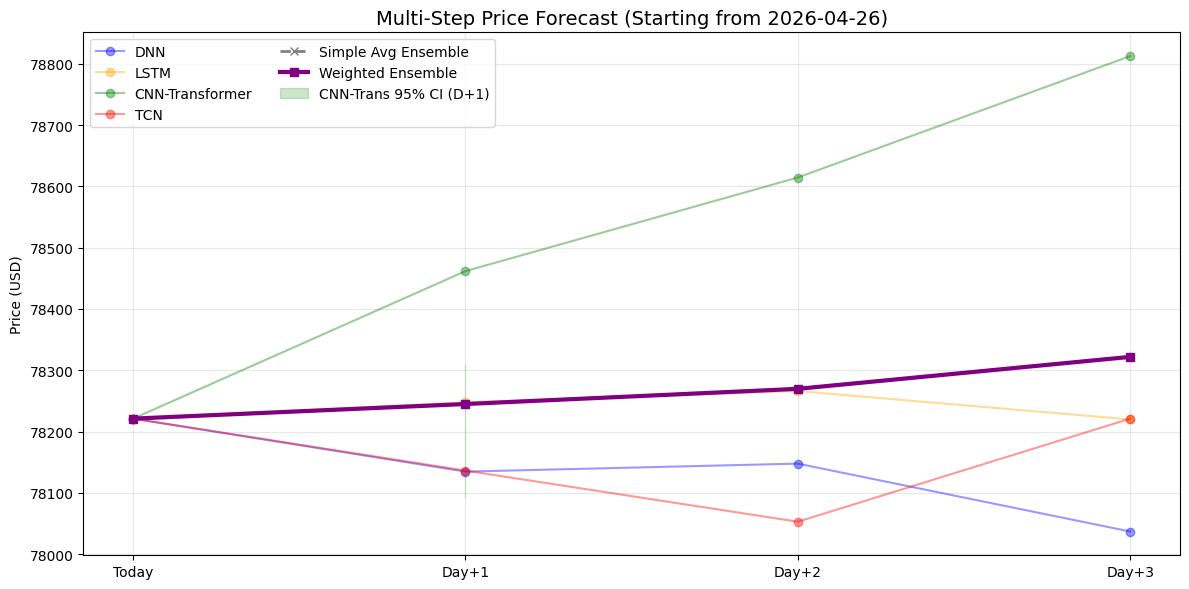

In [29]:
# ============================================================
# SECTION 19B: Visualize Real-Time Multi-Step Forecasts & Summary
# ============================================================

# 1. Create Comparison Table for Ensembles
ens_avg_p1 = anchor_price * np.exp(target_scaler.inverse_transform(avg_scaled[:, 0:1])[0][0])
ens_wted_p1 = anchor_price * np.exp(target_scaler.inverse_transform(w_scaled[:, 0:1])[0][0])

ensemble_comparison = pd.DataFrame({
    'Ensemble Method': ['Simple Average', 'Weighted (by Val MAPE)'],
    'Logic': ['Mean of all 4 models', 'Inverse-error weighting'],
    'Predicted Price (Day+1)': [f'${ens_avg_p1:,.2f}', f'${ens_wted_p1:,.2f}'],
    'Difference ($)': ['-', f'${abs(ens_avg_p1 - ens_wted_p1):,.2f}']
})

print("\n📊 Ensemble Logic Comparison:")
display(ensemble_comparison)

# 2. Plotting the Trajectory
plt.figure(figsize=(12, 6))
forecast_steps = ['Today', 'Day+1', 'Day+2', 'Day+3']
x_axis = np.arange(len(forecast_steps))
colors = {'DNN': 'blue', 'LSTM': 'orange', 'CNN-Transformer': 'green', 'TCN': 'red'}

for name, model_scaled_preds in live_preds_scaled.items():
    path = [anchor_price]
    log_rets = target_scaler.inverse_transform(model_scaled_preds.reshape(-1, 1)).ravel()
    p = anchor_price
    for r in log_rets:
        p = p * np.exp(r)
        path.append(p)
    plt.plot(x_axis, path, marker='o', label=name, color=colors.get(name, 'gray'), linewidth=1.5, alpha=0.4)

# Add Simple Average Ensemble Path
avg_log_rets = target_scaler.inverse_transform(avg_scaled.reshape(-1, 1)).ravel()
avg_path = [anchor_price]
p_avg = anchor_price
for r in avg_log_rets:
    p_avg = p_avg * np.exp(r)
    avg_path.append(p_avg)
plt.plot(x_axis, avg_path, marker='x', label='Simple Avg Ensemble', color='gray', linewidth=2, linestyle='--')

# Add Weighted Ensemble Path
w_log_rets = target_scaler.inverse_transform(w_scaled.reshape(-1, 1)).ravel()
ens_path = [anchor_price]
p_ens = anchor_price
for r in w_log_rets:
    p_ens = p_ens * np.exp(r)
    ens_path.append(p_ens)
plt.plot(x_axis, ens_path, marker='s', label='Weighted Ensemble', color='purple', linewidth=3)

# Add Uncertainty Band for CNN-Transformer
mc_log_rets_d1 = target_scaler.inverse_transform(mc_mean[0:1].reshape(-1, 1)).ravel()[0]
mc_p1 = anchor_price * np.exp(mc_log_rets_d1)
plt.fill_between([1], [mc_p1 - 1.96*usd_std], [mc_p1 + 1.96*usd_std], color='green', alpha=0.2, label='CNN-Trans 95% CI (D+1)')

plt.title(f'Multi-Step Price Forecast (Starting from {live_df.index[-1].date()})', fontsize=14)
plt.ylabel('Price (USD)')
plt.xticks(x_axis, forecast_steps)
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()